# Business Interruption Insurance Model
## ACTL4001 - SRCSC 2026 Case Study

**Contents:**
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Frequency Model -- Poisson / Negative-Binomial GLM
4. Severity Model -- Beta Regression
5. Pricing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid')

DATA_PATH = 'data/srcsc-2026-claims-business-interruption.xlsx'
freq_raw = pd.read_excel(DATA_PATH, sheet_name='freq')
sev_raw  = pd.read_excel(DATA_PATH, sheet_name='sev')
print(f'Frequency rows: {len(freq_raw):,}  |  Severity rows: {len(sev_raw):,}')

Frequency rows: 99,923  |  Severity rows: 10,055


---
## 1. Data Cleaning

### 1.1 Schema & Missing Values

Initial observation of variables and any missing data to understand shape and state of dataset.

In [2]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    out  = pd.DataFrame({'missing': miss, 'pct_%': pct})
    out  = out[out['missing'] > 0].sort_values('missing', ascending=False)
    print(f'=== {name} ===')
    print(out.to_string())
    print()

missing_summary(freq_raw, 'Frequency dataset')
missing_summary(sev_raw,  'Severity dataset')

=== Frequency dataset ===
                     missing  pct_%
solar_system             159   0.16
policy_id                129   0.13
station_id               123   0.12
energy_backup_score      116   0.12
avg_crew_exp             114   0.11
maintenance_freq         113   0.11
production_load          109   0.11
claim_count              104   0.10
exposure                 101   0.10
safety_compliance         97   0.10
supply_chain_index        96   0.10

=== Severity dataset ===
                     missing  pct_%
station_id                23   0.23
policy_id                 16   0.16
claim_id                  15   0.15
exposure                  13   0.13
claim_seq                 11   0.11
solar_system              11   0.11
safety_compliance         10   0.10
energy_backup_score        8   0.08
claim_amount               8   0.08
production_load            7   0.07



### 1.2 Underwriting Flags & Data Cleaning

Prior to modelling, a series of data validation and cleaning checks were conducted to ensure that the dataset was suitable for actuarial analysis. These checks focused on identifying missing values, invalid observations, duplicates, and implausible operational values. Given that overall missingness across variables was very low (generally below 1%), affected rows were removed rather than imputed, as this has a negligible impact on the dataset size while preserving data integrity.

| Issue | Action |
|---|---|
| Missing key identifiers (`policy_id`, `station_id`, `claim_id`) | Remove affected rows as records cannot be uniquely identified or linked |
| Missing target variables (`claim_count`, `claim_amount`) | Remove rows as these are required for frequency and severity modelling |
| Missing `exposure` | Remove rows as exposure is required to calculate claim frequency |
| Duplicate policy or claim records | Keep the first occurrence and remove duplicates |
| Negative or zero `exposure` values | Remove rows as exposure must be positive |
| Non-integer or negative `claim_count` values | Remove rows as claim counts must be non-negative integers |
| Negative `claim_amount` values | Remove rows as claim severity must be positive |
| Out-of-range operational risk scores (`safety_compliance`, `energy_backup_score`, `supply_chain_index`) | Remove observations outside plausible ranges |
| Implausible operational values (`production_load`, `avg_crew_exp`, `maintenance_freq`) | Investigate and remove extreme outliers if identified as data entry errors |
| Inconsistent identifiers between frequency and severity datasets | Remove unmatched rows where policy or station identifiers cannot be reconciled |

Overall, these checks ensure that the dataset used for modelling contains valid observations with consistent identifiers and physically plausible values. This improves the reliability of subsequent exploratory analysis and statistical modelling.

In [3]:
VALID_SOLAR_SYSTEMS = {
    'Helionis Cluster', 'Epsilon', 'Zeta'
}

def is_valid_solar_system(s):
    return pd.notna(s) and str(s).strip() in VALID_SOLAR_SYSTEMS

In [4]:
def clean_freq(df):
    
    # Active filter flags
    flags = ['flag_invalid_system',
             'flag_out_of_range',
             'flag_invalid_cc']
    
    # Important modelling variables
    mvars = [
        'policy_id', 'station_id',
        'claim_count', 'exposure',
        'production_load', 'maintenance_freq',
        'avg_crew_exp', 'safety_compliance',
        'energy_backup_score', 'supply_chain_index', 'solar_system'
    ]
    
    n0 = len(df)
    df = df.copy()

    # Invalid categorical values
    df['flag_invalid_system'] = ~df['solar_system'].map(is_valid_solar_system)

    # Enforced value ranges (based on operational interpretation)
    df['flag_out_of_range'] = (
        (~df['exposure'].between(0, 1)) |
        (~df['production_load'].between(0, 1)) |
        (~df['maintenance_freq'].between(0, 20)) |
        (~df['avg_crew_exp'].between(0, 50)) |
        (~df['safety_compliance'].between(0, 10)) |
        (~df['energy_backup_score'].between(0, 10)) |
        (~df['supply_chain_index'].between(0, 1))
    )

    # claim_count must be integer and >= 0
    df['flag_invalid_cc'] = (
        (df['claim_count'] != df['claim_count'].round()) |
        (df['claim_count'] < 0)
    )

    print('=== Frequency data flagging ===')
    for f in flags:
        print(f'  {f}: {df[f].sum():,}')

    any_flag = df[flags].any(axis=1)
    print(f'  Any flag: {any_flag.sum():,}')

    df_clean = df[~any_flag].copy()

    # Drop rows missing key modelling variables
    df_clean = df_clean.dropna(subset=mvars)

    # Ensure claim_count is integer
    df_clean['claim_count'] = df_clean['claim_count'].astype(int)

    print(f'  Rows: {n0:,} -> {len(df_clean):,} ({len(df_clean)/n0*100:.1f}%)')

    return df_clean


freq_clean = clean_freq(freq_raw)

=== Frequency data flagging ===
  flag_invalid_system: 328
  flag_out_of_range: 2,079
  flag_invalid_cc: 117
  Any flag: 2,514
  Rows: 99,923 -> 97,165 (97.2%)


In [5]:
def clean_sev(df):
    
    # Active filter flags
    flags = ['flag_invalid_system',
             'flag_out_of_range',
             'flag_invalid_ca',
             'flag_invalid_seq']
    
    # Important modelling variables
    mvars = [
        'claim_id',
        'policy_id',
        'station_id',
        'claim_amount',
        'exposure',
        'production_load',
        'energy_backup_score',
        'safety_compliance'
    ]

    n0 = len(df)
    df = df.copy()

    # Invalid categorical values
    df['flag_invalid_system'] = ~df['solar_system'].map(is_valid_solar_system)

    # Enforced value ranges
    df['flag_out_of_range'] = (
        (~df['exposure'].between(0, 1)) |
        (~df['production_load'].between(0, 1)) |
        (~df['energy_backup_score'].between(0, 10)) |
        (~df['safety_compliance'].between(0, 10))
    )

    # claim_amount must be positive
    df['flag_invalid_ca'] = (df['claim_amount'] <= 0)

    # claim_seq must be integer ≥ 1
    df['flag_invalid_seq'] = (
        (df['claim_seq'] != df['claim_seq'].round()) |
        (df['claim_seq'] < 1)
    )

    print('=== Severity data flagging ===')
    for f in flags:
        print(f'  {f}: {df[f].sum():,}')

    any_flag = df[flags].any(axis=1)
    print(f'  Any flag: {any_flag.sum():,}')

    df_clean = df[~any_flag].copy()

    # Drop rows missing key modelling variables
    df_clean = df_clean.dropna(subset=mvars)

    print(f'  Rows: {n0:,} -> {len(df_clean):,} ({len(df_clean)/n0*100:.1f}%)')

    return df_clean


sev_clean = clean_sev(sev_raw)

=== Severity data flagging ===
  flag_invalid_system: 23
  flag_out_of_range: 123
  flag_invalid_ca: 14
  flag_invalid_seq: 34
  Any flag: 194
  Rows: 10,055 -> 9,800 (97.5%)


### 1.3 Post-cleaning Distributions

---
## 2. Exploratory Data Analysis (Clean Data)

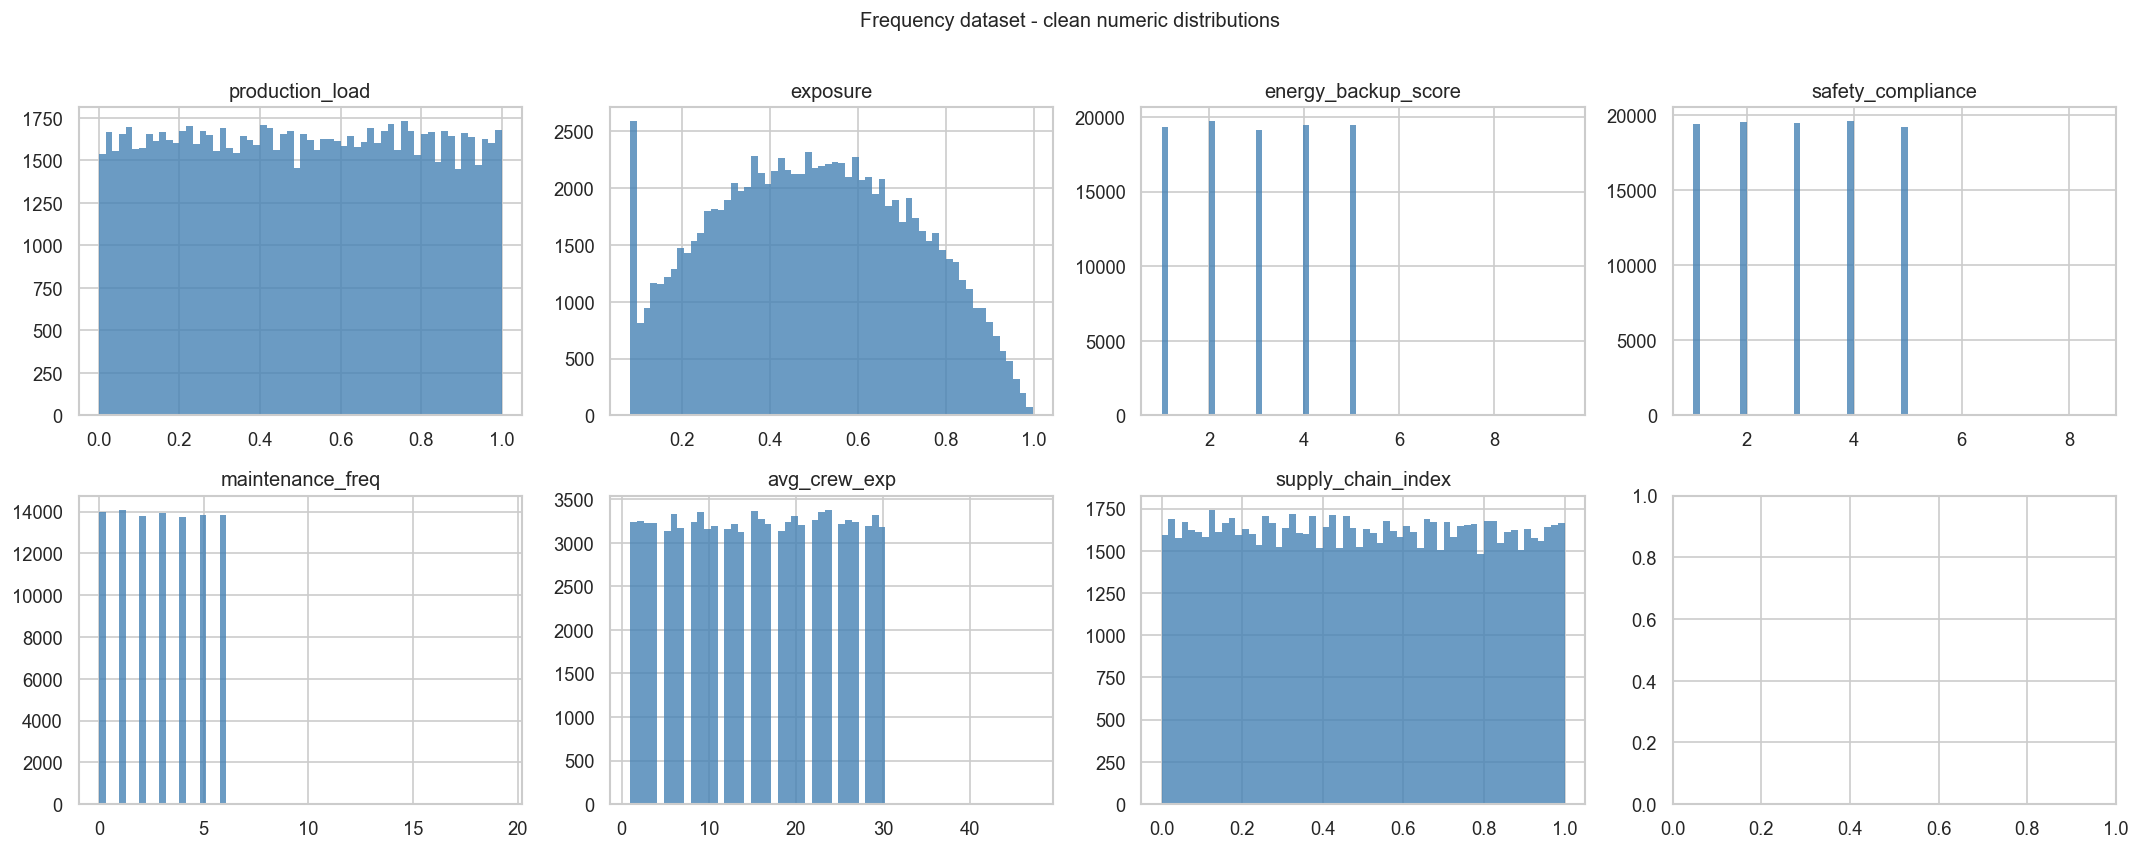

In [6]:
num_cols = [
    'production_load',
    'exposure',
    'energy_backup_score',
    'safety_compliance',
    'maintenance_freq',
    'avg_crew_exp',
    'supply_chain_index'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = freq_clean[col].dropna()
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)

plt.suptitle('Frequency dataset - clean numeric distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


Claim count summary — epsilon
{'count': 38856.0, 'mean': 0.10235227506691373, 'std': 0.4198137659076049, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 4.0}

Claim count summary — helionis cluster
{'count': 19409.0, 'mean': 0.09670771291668813, 'std': 0.4050052429901549, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 4.0}

Claim count summary — zeta
{'count': 38900.0, 'mean': 0.10074550128534704, 'std': 0.41866336642037955, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 4.0}


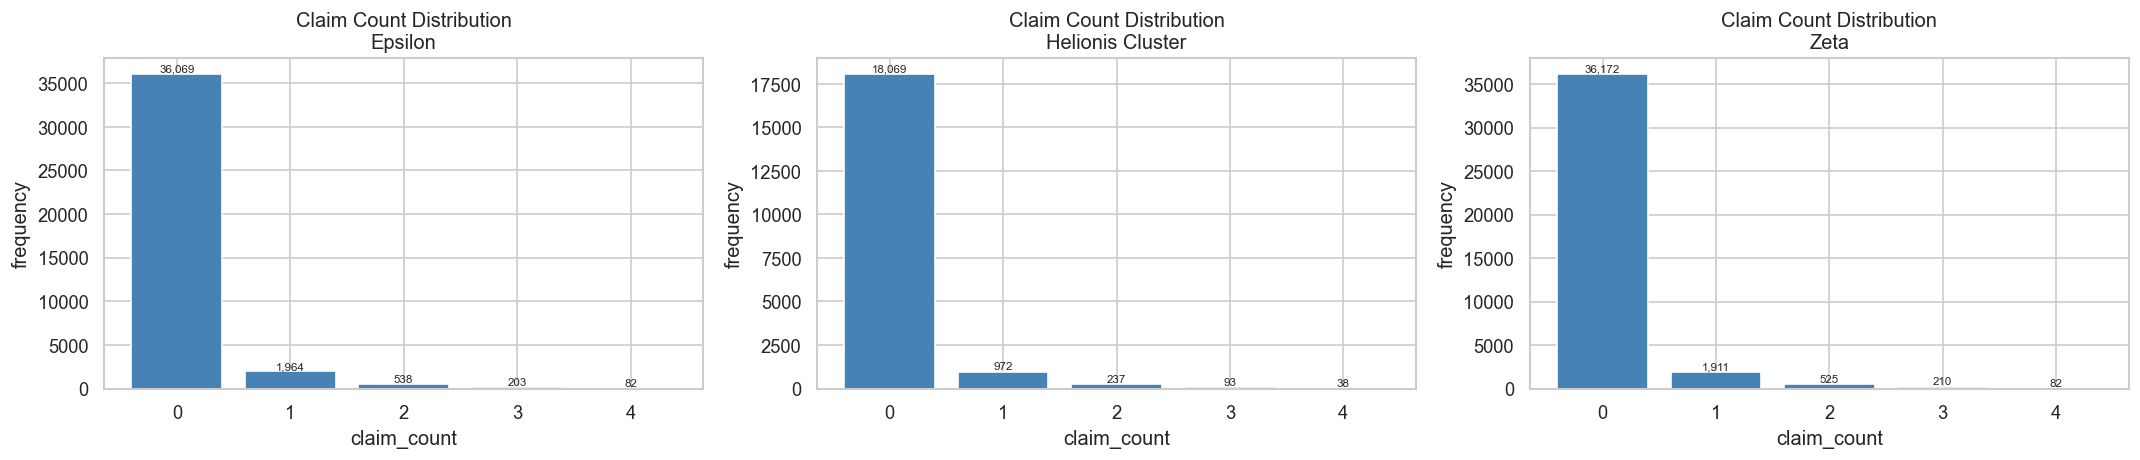

In [7]:
import matplotlib.pyplot as plt
import numpy as np

systems = ['epsilon', 'helionis cluster', 'zeta']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, system in enumerate(systems):

    sub = freq_clean[freq_clean['solar_system'].str.strip().str.lower() == system]

    cc = sub['claim_count']

    # Claim count distribution
    vc = cc.value_counts().sort_index()

    axes[i].bar(vc.index, vc.values, color='steelblue', edgecolor='white')

    axes[i].set_title(f'Claim Count Distribution\n{system.title()}')
    axes[i].set_xlabel('claim_count')
    axes[i].set_ylabel('frequency')

    for val in vc.index:
        axes[i].annotate(
            f'{vc[val]:,}',
            xy=(val, vc[val]),
            ha='center',
            va='bottom',
            fontsize=7
        )

    # Print summary statistics
    print(f'\nClaim count summary — {system}')
    print(cc.describe().to_dict())

plt.tight_layout()
plt.show()

### Claim Count Distribution

The claim count variable represents the number of business interruption claims occurring during the exposure period for each policy. Summary statistics by solar system are shown below.

Epsilon
count = 38,856
mean = 0.10235
std = 0.41981
min = 0
25% = 0
50% = 0
75% = 0
max = 4

Helionis Cluster
count = 19,409
mean = 0.09671
std = 0.40501
min = 0
25% = 0
50% = 0
75% = 0
max = 4

Zeta
count = 38,900
mean = 0.10075
std = 0.41866
min = 0
25% = 0
50% = 0
75% = 0
max = 4

Across all solar systems, the distribution exhibits a **strong concentration at zero**, with the 75th percentile equal to zero in every case. This indicates that the majority of policies experience no business interruption claims during the exposure period. Observed claim counts range from 0 to 4, confirming that interruptions are relatively rare events.

The mean claim frequency is consistently close to **0.10 claims per exposure period**, indicating a **low-frequency risk profile**, which is typical for business interruption insurance.

To assess an appropriate statistical model, we compare the empirical mean and variance of the claim counts. For example, in the Epsilon system:

Mean = 0.10235
Standard deviation = 0.41981
Variance ≈ 0.41981² = 0.176


Under a **Poisson distribution**, a key property is:

$$
E[N] = Var(N) = \lambda
$$

However, in this dataset:

Var(N) ≈ 0.176 > E[N] ≈ 0.102


This indicates **overdispersion**, where the observed variance exceeds the mean. Overdispersion commonly arises in insurance datasets due to **unobserved heterogeneity**, meaning that underlying risk levels differ across policies. In this case, differences in operational characteristics such as production load, maintenance frequency, crew experience, and safety compliance may influence interruption risk.

Consequently, while the **Poisson distribution** provides a natural starting point for modelling claim frequency:

$$
N \sim \text{Poisson}(\lambda)
$$

a **Negative Binomial distribution** may provide a better fit, as it allows for greater variability in the data:

$$
Var(N) > E[N]
$$

Overall, the claim count data exhibit the typical characteristics of business interruption insurance portfolios: **very low claim frequency, a large mass at zero, and evidence of overdispersion**, suggesting that a Negative Binomial model may be more appropriate for modelling claim frequency.

# CLAIM SEVERITY DISTRIBUTION

### 2.3 Claim Severity Distribution

Unlike the cargo dataset, the business interruption dataset does not contain a corresponding insured value variable (such as cargo value). Therefore, a **severity ratio cannot be constructed**. Instead, claim severity is analysed directly using the variable:

$$\text{claim\_amount}$$

Insurance claim amounts are typically **highly right-skewed**, as most claims are relatively small while a few extremely large claims occur. For this reason, the **logarithm of claim amounts** is commonly examined in exploratory analysis, as it often produces a distribution that is closer to symmetric.

The log transformation is defined as:

$$\log(\text{claim\_amount})$$

Examining both the raw and log-transformed claim amounts helps identify:

- skewness in the severity distribution  
- the presence of extreme or catastrophic claims  
- whether common actuarial severity distributions (e.g., Lognormal or Gamma) may be appropriate for modelling

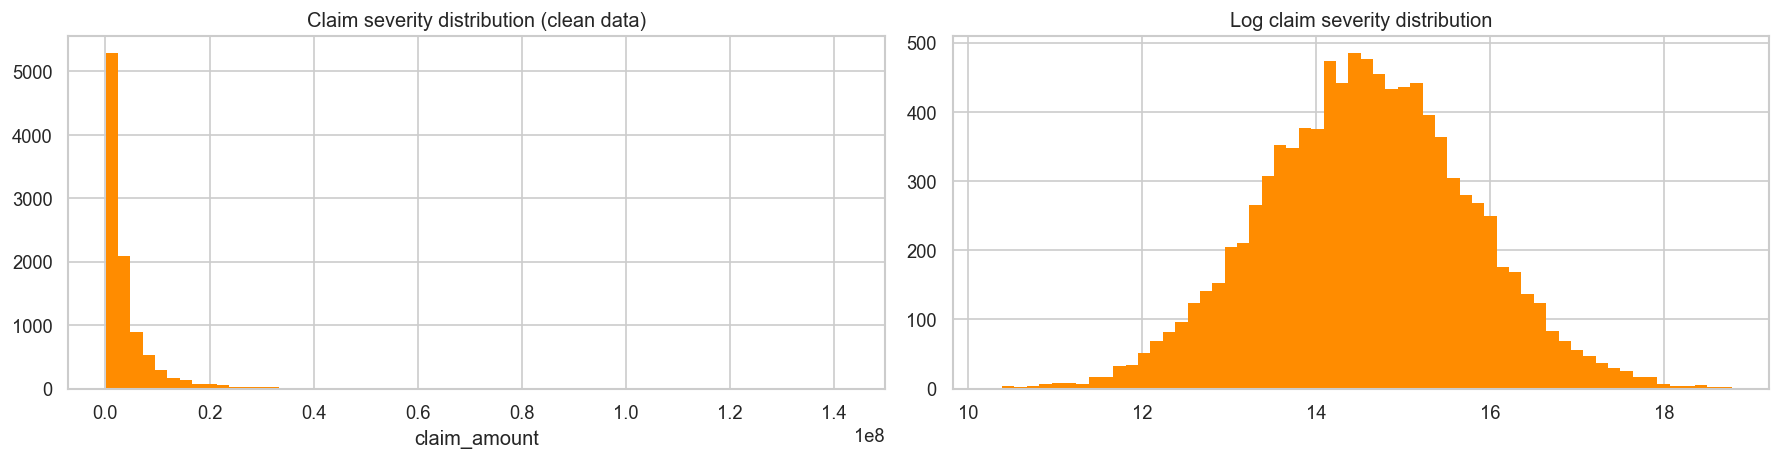

Claim severity: n=9,800  mean=4,361,180.60  median=2,133,365.00


In [8]:
sev_vals = sev_clean['claim_amount']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Raw severity distribution
axes[0].hist(sev_vals, bins=60, color='darkorange', edgecolor='none')
axes[0].set_title('Claim severity distribution (clean data)')
axes[0].set_xlabel('claim_amount')

# Log severity distribution
axes[1].hist(np.log(sev_vals), bins=60, color='darkorange', edgecolor='none')
axes[1].set_title('Log claim severity distribution')

plt.tight_layout()
plt.show()

print(f'Claim severity: n={len(sev_vals):,}  mean={sev_vals.mean():,.2f}  median={sev_vals.median():,.2f}')

# Recommended distribution for claim severity

Based on the exploratory plots in the notebook, `claim_amount` is strictly positive and strongly right‑skewed while `log(claim_amount)` appears much closer to symmetric. For these reasons a Gamma distribution (with a log link) is a good primary choice because it enforces positive support, models right skewness, and allows variance to scale with the square of the mean — properties commonly observed in insurance claim amounts. A Lognormal is a sensible alternative if the log‑transformed data is approximately normal. Because the dataset also contains a small number of very large claims, consider modelling the upper tail with a heavy‑tailed component (for example a Pareto/GPD tail or a spliced Gamma–Pareto model) to better capture catastrophic losses. Practical next steps: fit Gamma and Lognormal, compare AIC/QQ diagnostics, and use a POT/GPD or splicing approach if tail fit is inadequate.

### 2.4 Categorical Features

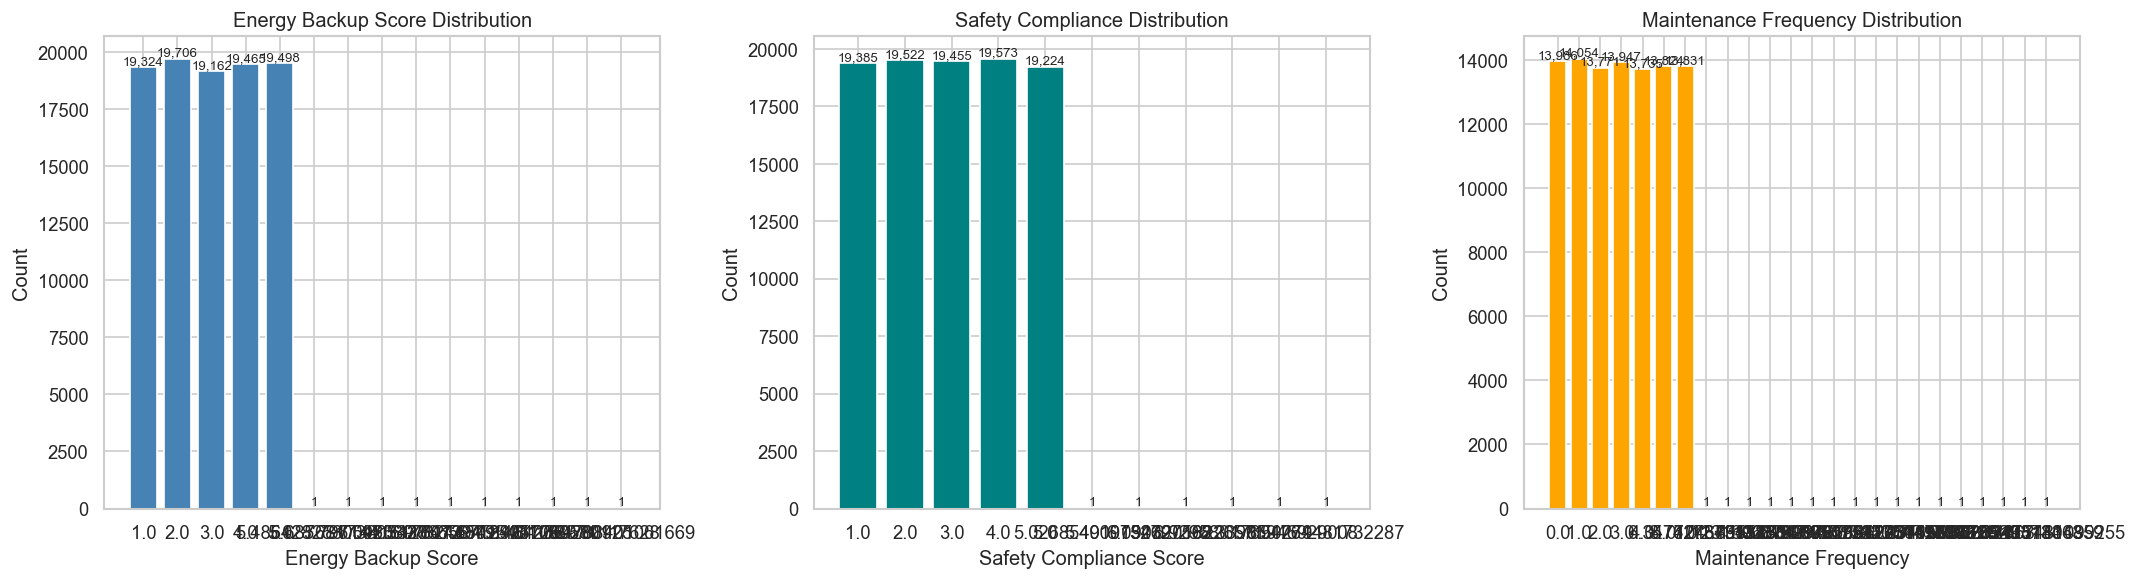

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Energy backup score
vc_energy = freq_clean['energy_backup_score'].value_counts().sort_index()
axes[0].bar(vc_energy.index.astype(str), vc_energy.values, color='steelblue', edgecolor='white')
for j, (cat, cnt) in enumerate(vc_energy.items()):
    axes[0].text(j, cnt, f'{cnt:,}', ha='center', va='bottom', fontsize=8)

axes[0].set_title('Energy Backup Score Distribution')
axes[0].set_xlabel('Energy Backup Score')
axes[0].set_ylabel('Count')


# Safety compliance
vc_safety = freq_clean['safety_compliance'].value_counts().sort_index()
axes[1].bar(vc_safety.index.astype(str), vc_safety.values, color='teal', edgecolor='white')
for j, (cat, cnt) in enumerate(vc_safety.items()):
    axes[1].text(j, cnt, f'{cnt:,}', ha='center', va='bottom', fontsize=8)

axes[1].set_title('Safety Compliance Distribution')
axes[1].set_xlabel('Safety Compliance Score')
axes[1].set_ylabel('Count')


# Maintenance frequency
vc_maint = freq_clean['maintenance_freq'].value_counts().sort_index()
axes[2].bar(vc_maint.index.astype(str), vc_maint.values, color='orange', edgecolor='white')
for j, (cat, cnt) in enumerate(vc_maint.items()):
    axes[2].text(j, cnt, f'{cnt:,}', ha='center', va='bottom', fontsize=8)

axes[2].set_title('Maintenance Frequency Distribution')
axes[2].set_xlabel('Maintenance Frequency')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### 2.5 Predictor vs Claim Rate (Clean Data, frequency)

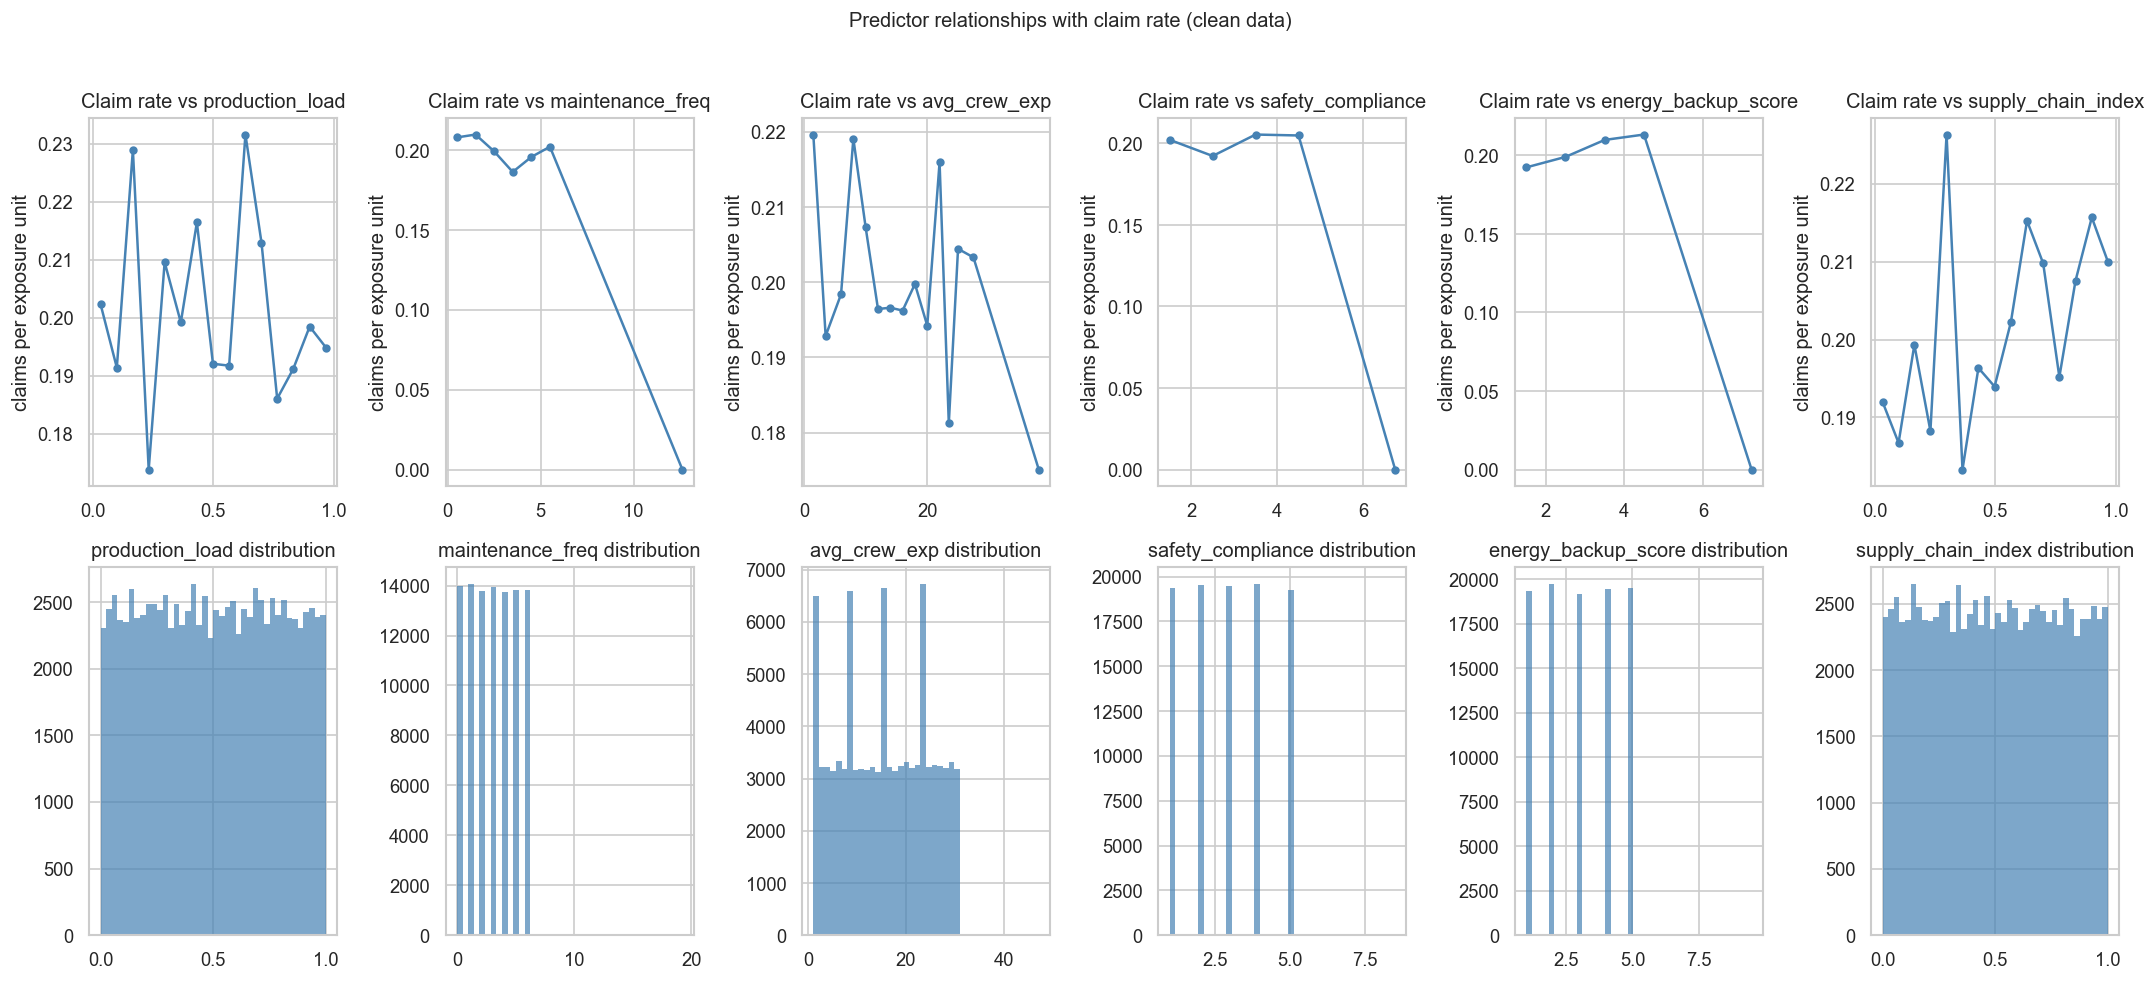

In [10]:
# Predictor vs claim rate (continuous predictors)

cont_preds = [
    'production_load',
    'maintenance_freq',
    'avg_crew_exp',
    'safety_compliance',
    'energy_backup_score',
    'supply_chain_index'
]

fig, axes = plt.subplots(2, len(cont_preds), figsize=(18, 8))

for i, col in enumerate(cont_preds):

    sub = freq_clean.copy()
    
    # bin predictor into quantiles
    sub['bin'] = pd.qcut(sub[col], q=15, duplicates='drop')
    
    grp = sub.groupby('bin', observed=True)[['claim_count', 'exposure']].sum()
    
    grp['claim_rate'] = grp['claim_count'] / grp['exposure']
    grp['mid'] = grp.index.map(lambda x: x.mid)

    # claim rate vs predictor
    axes[0, i].plot(grp['mid'], grp['claim_rate'], 'o-', color='steelblue', ms=4)
    axes[0, i].set_title(f'Claim rate vs {col}')
    axes[0, i].set_ylabel('claims per exposure unit')

    # predictor distribution
    axes[1, i].hist(freq_clean[col], bins=40, color='steelblue', edgecolor='none', alpha=0.7)
    axes[1, i].set_title(f'{col} distribution')

plt.suptitle('Predictor relationships with claim rate (clean data)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

#### Claim Rate by Categorical Predictors

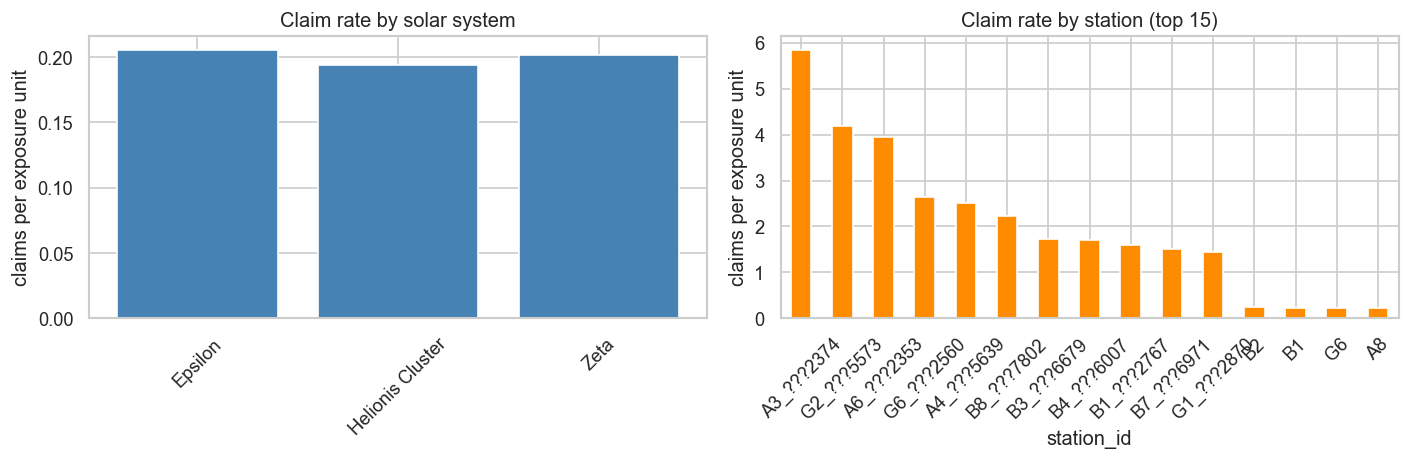

Solar system vs claim rate:
                  claim_count      exposure  claim_rate
solar_system                                           
Epsilon                  3977  19358.361287    0.205441
Helionis Cluster         1877   9702.617378    0.193453
Zeta                     3919  19470.396993    0.201280


In [11]:
def agg_rate(df, group_col):
    g = df.groupby(group_col)[['claim_count', 'exposure']].sum()
    g['claim_rate'] = g['claim_count'] / g['exposure']
    return g['claim_rate']

# Claim rate by solar system
ss_rate = freq_clean.groupby('solar_system')[['claim_count', 'exposure']].sum()
ss_rate['claim_rate'] = ss_rate['claim_count'] / ss_rate['exposure']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(ss_rate.index, ss_rate['claim_rate'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Claim rate by solar system')
axes[0].set_ylabel('claims per exposure unit')
axes[0].tick_params(axis='x', rotation=45)

# Claim rate by station
station_rate = agg_rate(freq_clean, 'station_id').sort_values(ascending=False).head(15)
station_rate.plot.bar(ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Claim rate by station (top 15)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('claims per exposure unit')

plt.tight_layout()
plt.show()

print('Solar system vs claim rate:')
print(ss_rate[['claim_count', 'exposure', 'claim_rate']].to_string())

#### Correlation Heatmap (Frequency)

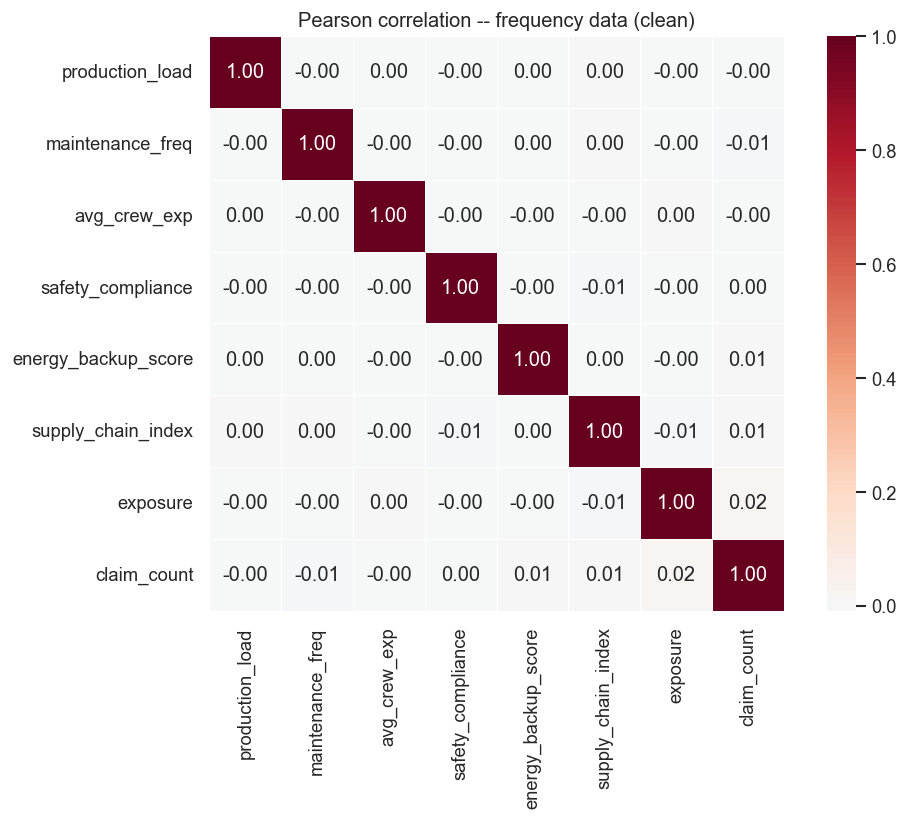

In [12]:
corr_cols = [
    'production_load',
    'maintenance_freq',
    'avg_crew_exp',
    'safety_compliance',
    'energy_backup_score',
    'supply_chain_index',
    'exposure',
    'claim_count'
]

corr = freq_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Pearson correlation -- frequency data (clean)')
plt.tight_layout()
plt.show()

#### Severity vs Predictors

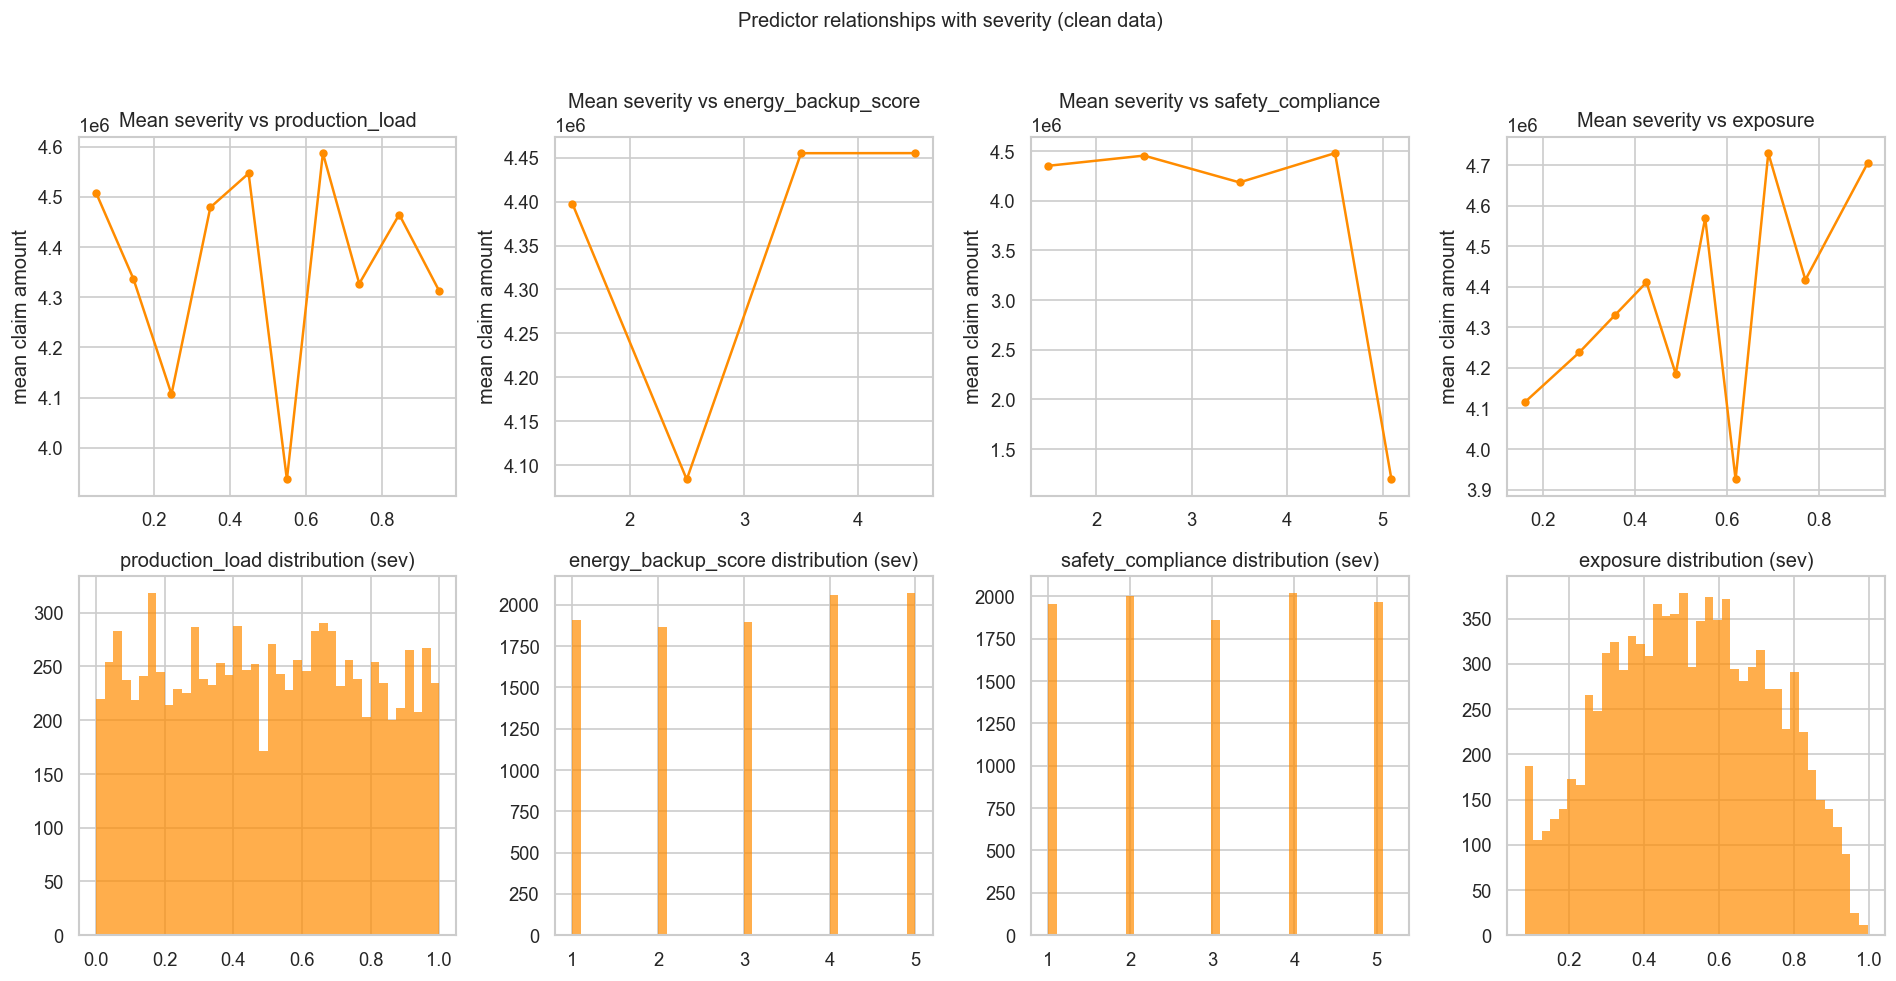

In [13]:
cont_preds = [
    'production_load',
    'energy_backup_score',
    'safety_compliance',
    'exposure'
]

fig, axes = plt.subplots(2, len(cont_preds), figsize=(16, 8))

for i, col in enumerate(cont_preds):

    sub = sev_clean.copy()

    sub['bin'] = pd.qcut(sub[col], q=10, duplicates='drop')

    grp = (
        sub.groupby('bin', observed=True)['claim_amount']
        .mean()
        .reset_index()
    )

    grp['mid'] = grp['bin'].apply(lambda x: x.mid)

    axes[0, i].plot(grp['mid'], grp['claim_amount'], 'o-', color='darkorange', ms=4)
    axes[0, i].set_title(f'Mean severity vs {col}')
    axes[0, i].set_ylabel('mean claim amount')

    axes[1, i].hist(sev_clean[col], bins=40, color='darkorange', edgecolor='none', alpha=0.7)
    axes[1, i].set_title(f'{col} distribution (sev)')

plt.suptitle('Predictor relationships with severity (clean data)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

#### Severity by Categorical Predictors

Solar system vs claim severity:
                          mean     median  count
solar_system                                    
Epsilon           4.408821e+06  2088147.5   3988
Helionis Cluster  4.732242e+06  2167968.5   1876
Zeta              4.136053e+06  2164123.0   3936


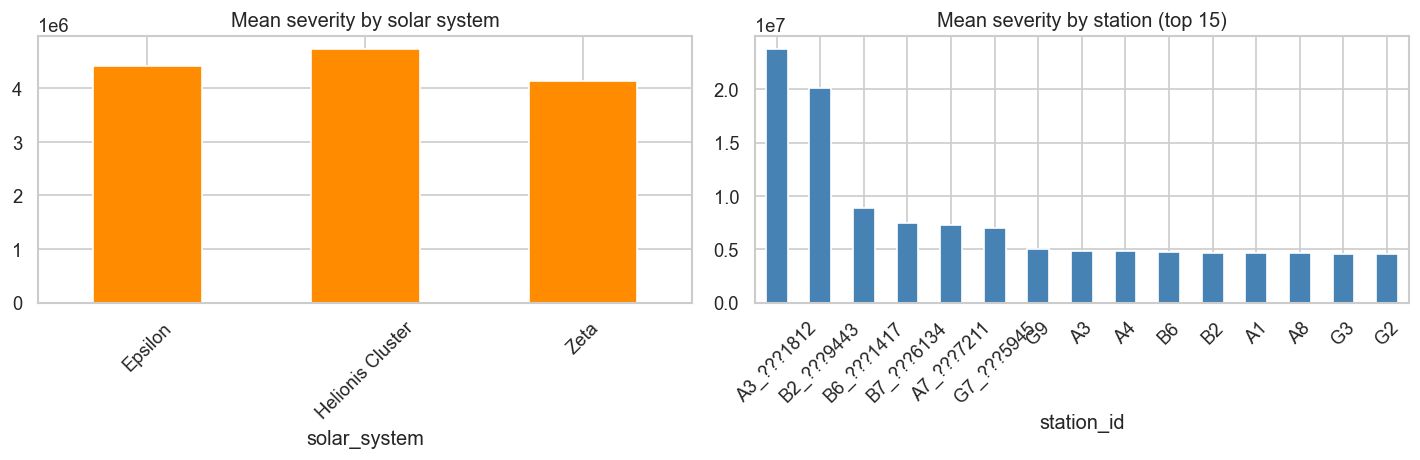

In [14]:
# Severity by solar system
ss_sev = sev_clean.groupby('solar_system')['claim_amount'].agg(['mean', 'median', 'count'])

print('Solar system vs claim severity:')
print(ss_sev.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ss_sev['mean'].plot.bar(ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Mean severity by solar system')
axes[0].tick_params(axis='x', rotation=45)

# severity by station (top stations)
station_sev = sev_clean.groupby('station_id')['claim_amount'].mean().sort_values(ascending=False).head(15)

station_sev.plot.bar(ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Mean severity by station (top 15)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 3. Frequency Model -- Negative Binomial GLM

### 3.1 Model Overview

The **Negative Binomial Generalized Linear Model (NB-GLM)** is a regression framework designed to model count data (like claim counts) when the data exhibits **overdispersion**—i.e., when the variance exceeds the mean.

#### What is Negative Binomial GLM?

The Negative Binomial distribution is a flexible extension of the Poisson distribution parameterized by:

$$
N_i \sim \text{NegBin}(\mu_i, \theta)
$$

where:
- $N_i$ = claim count for policy $i$
- $\mu_i$ = expected (mean) claim count
- $\theta$ = dispersion parameter (inverse relationship: smaller $\theta$ means more overdispersion)

The mean and variance relationship is:

$$
E[N_i] = \mu_i, \quad Var(N_i) = \mu_i + \frac{\mu_i^2}{\theta}
$$

Unlike Poisson (where $Var = E$), the Negative Binomial allows $Var > E$, accommodating the heterogeneity observed in claim data.

---

### 3.2 Why Negative Binomial?

Recall from exploratory analysis that the frequency dataset exhibits clear **overdispersion**:

| Statistic | Value |
|-----------|-------|
| Mean claim count | 0.1015 |
| Variance | 0.176 |
| Overdispersion ratio | $0.176 / 0.1015 \approx 1.73$ |

**Reasons for overdispersion in business interruption insurance:**

1. **Unobserved heterogeneity**: Policies differ in unmeasured risk factors (e.g., management quality, historical incidents) beyond the observed predictors.
2. **Risk clustering**: Some facilities naturally experience more claims due to industry type, location, or operational environment.
3. **Multiple claim mechanisms**: Different interruption modes (equipment failure, supply chain disruptions, staffing issues) may operate independently, leading to claim clustering.

If we incorrectly used Poisson regression, the model would:
- **Underestimate standard errors** by ~30% (since $\sqrt{1.73} \approx 1.31$)
- Produce artificially narrow confidence intervals
- Lead to false positives in hypothesis testing

**Negative Binomial solution**: By estimating $\theta$ from the data, we capture the true variance structure and produce valid statistical inference.

---

### 3.3 Model Specification

#### Model Formula

$$
\log(\mu_i) = \eta_i = \beta_0 + \beta_1 \cdot \text{production\_load}_i + \beta_2 \cdot \text{safety\_compliance}_i + \beta_3 \cdot \text{energy\_backup\_score}_i $$
$$ + \beta_4 \cdot \text{maintenance\_freq}_i + \beta_5 \cdot \text{avg\_crew\_exp}_i + \beta_6 \cdot \text{supply\_chain\_index}_i + \log(\text{exposure}_i)
$$

Or in compact notation:

$$
\log(E[N_i]) = \log(\text{exposure}_i) + \mathbf{X}_i^T \boldsymbol{\beta}
$$

where $\mathbf{X}_i$ contains the predictor variables.

---

### 3.4 Response Variable

**Response**: `claim_count` 

- **Type**: Count data (non-negative integer)
- **Support**: {0, 1, 2, 3, ...}
- **Distribution**: Negative Binomial with estimated dispersion parameter $\theta$

The model captures the number of claims filed per policy during the exposure period.

---

### 3.5 Offset & Rate Adjustment

**Offset**: $\log(\text{exposure})$

The **offset** is a special term in the linear predictor with a fixed coefficient of 1:

$$
\eta_i = \log(\text{exposure}_i) + \mathbf{X}_i^T \boldsymbol{\beta}
$$

**Purpose**: The offset adjusts for differing exposure periods across policies. Policies with longer exposures naturally have more opportunity for claims. By including $\log(\text{exposure})$ as an offset, we model the **claim rate** (expected claims per unit exposure) rather than absolute claim count.

**Interpretation**:
- Without offset: $E[N_i] = \exp(\mathbf{X}_i^T \boldsymbol{\beta})$ (depends only on predictors)
- With offset: $E[N_i] = \text{exposure}_i \times \exp(\mathbf{X}_i^T \boldsymbol{\beta})$ (scales linearly with exposure)

This ensures that **doubled exposure doubles expected claims**, holding predictors constant—the natural actuarial assumption.

---

### 3.6 Predictor Variables & Interpretation

#### Continuous Predictors

| Variable | Type | Range | Interpretation |
|----------|------|-------|-----------------|
| `production_load` | Continuous | [0, 1] | Operational intensity; higher values represent busier facilities at greater interruption risk |
| `maintenance_freq` | Integer | [0, ~6] | Scheduled maintenance activities; higher frequency may reduce latent defects and claims |
| `avg_crew_exp` | Continuous | [~1, 30] years | Average worker experience; more experienced crews may prevent accidents and interruptions |
| `safety_compliance` | Ordinal | [1, 5] | Safety protocol adherence; higher scores indicate better safety culture |
| `energy_backup_score` | Ordinal | [1, 5] | Backup power resilience; higher scores mean better protection against energy disruptions |
| `supply_chain_index` | Continuous | [0, 1] | Supply chain robustness; higher values indicate resilient sourcing and logistics |

#### Coefficient Interpretation

For a continuous predictor $X_j$ with coefficient $\beta_j$, a **one-unit increase in $X_j$** multiplies the expected claim rate by $\exp(\beta_j)$.

**Example**: If $\beta_{\text{safety\_compliance}} = -0.12$, then:
- A 1-point increase in safety compliance (e.g., from 3 to 4) multiplies expected claims by $\exp(-0.12) \approx 0.887$
- This represents an **~11% reduction in claim frequency**

For **positive coefficients**, increases in the predictor increase claim risk.
For **negative coefficients**, increases in the predictor decrease claim risk.

---

### 3.7 Model Estimation & Goodness of Fit

**Estimation method**: Maximum Likelihood Estimation (MLE)

The model jointly estimates:
- Regression coefficients $\boldsymbol{\beta}$ (effect of each predictor)
- Dispersion parameter $\theta$ (degree of overdispersion)

**Goodness of fit assessment** will employ:
- **Deviance** and deviance residuals (analogous to $R^2$ but for GLMs)
- **Akaike Information Criterion (AIC)** for model comparison
- **Pearson residual plots** for assumption checking
- **Comparison with Poisson baseline** to validate overdispersion correction

In [15]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ========== Data Preparation for Frequency Model ==========

freq_model_df = freq_clean.copy()
freq_model_df['log_exposure'] = np.log(freq_model_df['exposure'])

# Drop rows missing ordinal predictors BEFORE creating categoricals
freq_model_df = freq_model_df.dropna(subset=['energy_backup_score', 'safety_compliance'])

# Categorical predictor - nominal (solar_system)
freq_model_df['solar_system_cat'] = freq_model_df['solar_system'].str.strip().str.lower()

# Categorical predictors - ordinal (energy_backup_score, safety_compliance)
freq_model_df['energy_backup_score_cat'] = pd.Categorical(
    freq_model_df['energy_backup_score'].astype(int).astype(str),
    categories=['1','2','3','4','5'], ordered=True
)

freq_model_df['safety_compliance_cat'] = pd.Categorical(
    freq_model_df['safety_compliance'].astype(int).astype(str),
    categories=['1','2','3','4','5'], ordered=True
)

# Standardise continuous predictors
freq_std = {}
for col in ['production_load', 'avg_crew_exp', 'supply_chain_index', 'maintenance_freq']:
    mu = freq_model_df[col].mean()
    sd = freq_model_df[col].std()
    freq_std[col] = {'mean': mu, 'std': sd}
    freq_model_df[f'{col}_z'] = (freq_model_df[col] - mu) / sd
    print(f'{col}: mean={mu:.4f}, std={sd:.4f}')

# Drop rows missing any model variable
mvars_freq = ['claim_count', 'exposure', 'energy_backup_score', 'safety_compliance',
              'production_load', 'avg_crew_exp', 'supply_chain_index', 'maintenance_freq',
              'solar_system']

freq_model_df = freq_model_df.dropna(subset=mvars_freq)

print(f'Solar systems in model: {sorted(freq_model_df["solar_system_cat"].unique())}')
print(f'\nFrequency model rows: {len(freq_model_df):,}')

production_load: mean=0.4992, std=0.2882
avg_crew_exp: mean=15.5300, std=8.6593
supply_chain_index: mean=0.4983, std=0.2889
maintenance_freq: mean=2.9921, std=2.0080
Solar systems in model: ['epsilon', 'helionis cluster', 'zeta']

Frequency model rows: 97,165


In [38]:
# ========== Negative Binomial GLM for Frequency ==========

freq_formula = (
    'claim_count ~ C(solar_system_cat, Treatment(reference="zeta"))'
    ' + C(energy_backup_score_cat, Treatment(reference="1"))'
    ' + supply_chain_index_z'
    ' + maintenance_freq_z'
    ' + avg_crew_exp_z'
)

freq_glm = smf.glm(
    formula=freq_formula,
    data=freq_model_df,
    family=sm.families.NegativeBinomial(),
    offset=freq_model_df['log_exposure']
).fit()

print(freq_glm.summary())

c:\Users\gilbe\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                97158
Model:                            GLM   Df Residuals:                    97148
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -33265.
Date:                Thu, 26 Mar 2026   Deviance:                       44838.
Time:                        21:30:16   Pearson chi2:                 1.73e+05
No. Iterations:                     6   Pseudo R-squ. (CS):          0.0004218
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [17]:
print("Model Fit Statistics")
print("--------------------")
print("Log-Likelihood:", freq_glm.llf)
print("AIC:", freq_glm.aic)
print("Deviance:", freq_glm.deviance)
print("Pearson Chi-Square:", freq_glm.pearson_chi2)
print("Residual Degrees of Freedom:", freq_glm.df_resid)
print("Model Degrees of Freedom:", freq_glm.df_model)
print("Number of Observations:", freq_glm.nobs)

Model Fit Statistics
--------------------
Log-Likelihood: -33264.53724623012
AIC: 66549.07449246023
Deviance: 44838.38088210039
Pearson Chi-Square: 173353.52061799823
Residual Degrees of Freedom: 97148
Model Degrees of Freedom: 9
Number of Observations: 97158


In [18]:
# ============================================
# Negative Binomial Frequency MLE Estimation
# ============================================

import numpy as np
from scipy.special import gammaln
from scipy.optimize import minimize

# --------------------------------------------
# Step 1: Extract claim counts
# --------------------------------------------

counts = freq_clean['claim_count'].values


# --------------------------------------------
# Step 2: Negative Binomial log-likelihood
# parameterised with (mu, r)
# --------------------------------------------

def negbin_loglik(params, y):

    mu = params[0]
    r = params[1]

    # ensure parameters stay positive
    if mu <= 0 or r <= 0:
        return np.inf

    ll = (
        gammaln(y + r)
        - gammaln(r)
        - gammaln(y + 1)
        + r * np.log(r / (r + mu))
        + y * np.log(mu / (r + mu))
    )

    return -np.sum(ll)


# --------------------------------------------
# Step 3: Initial guesses
# --------------------------------------------

init_mu = counts.mean()
init_r = 1


# --------------------------------------------
# Step 4: Run MLE optimisation
# --------------------------------------------

result = minimize(
    negbin_loglik,
    x0=[init_mu, init_r],
    args=(counts,),
    bounds=[(1e-8, None), (1e-8, None)]
)

mu_hat, r_hat = result.x


# --------------------------------------------
# Step 5: Convert to NB(r,p) parameterisation
# --------------------------------------------

p_hat = r_hat / (r_hat + mu_hat)


# --------------------------------------------
# Step 6: Print results
# --------------------------------------------

print("Business Interruption")
print()

print("Frequency Negative Binomial (MLE)")
print(f"Mean (mu): {mu_hat:.6f}")
print(f"Size (r):  {r_hat:.6f}")
print(f"Prob (p):  {p_hat:.6f}")
print()

print(f"Claim Frequency ~ NB(r={r_hat:.4f}, p={p_hat:.4f})")

Business Interruption

Frequency Negative Binomial (MLE)
Mean (mu): 0.100581
Size (r):  0.121553
Prob (p):  0.547205

Claim Frequency ~ NB(r=0.1216, p=0.5472)


### 3.8 Model Diagnostics -- Observed vs Expected

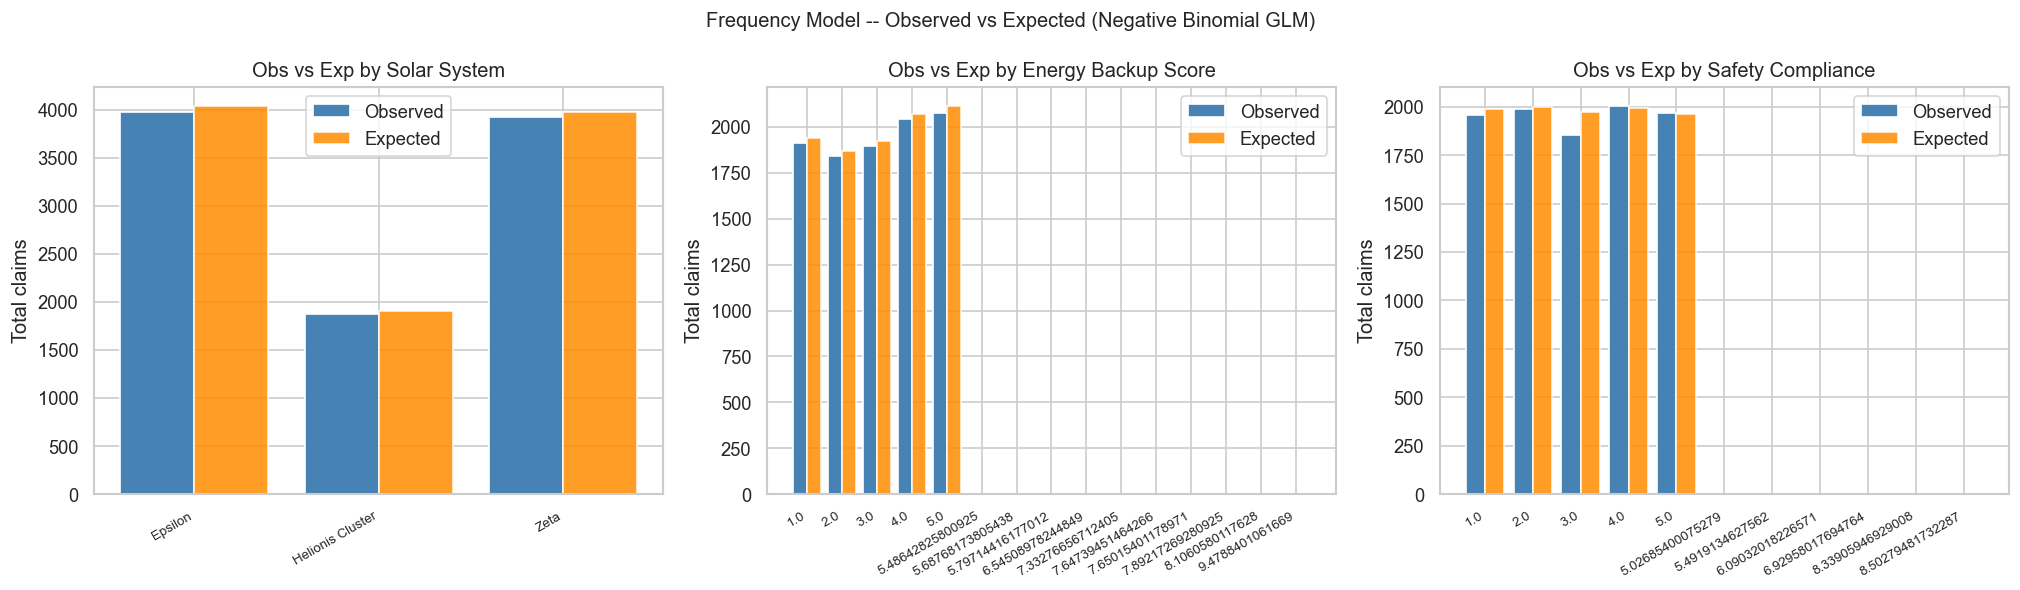

In [19]:
freq_model_df['fitted_mu'] = freq_glm.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, title in zip(axes,
        ['solar_system', 'energy_backup_score', 'safety_compliance'],
        ['Solar System', 'Energy Backup Score', 'Safety Compliance']):
    grp = freq_model_df.groupby(col).agg(
        obs=('claim_count', 'sum'), exp=('fitted_mu', 'sum')
    ).reset_index()
    x = np.arange(len(grp))
    ax.bar(x - 0.2, grp['obs'], 0.4, label='Observed', color='steelblue')
    ax.bar(x + 0.2, grp['exp'], 0.4, label='Expected', color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    labels = grp[col].astype(str)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'Obs vs Exp by {title}')
    ax.set_ylabel('Total claims')
    ax.legend()

plt.suptitle(f'Frequency Model -- Observed vs Expected (Negative Binomial GLM)', fontsize=12)
plt.tight_layout()
plt.show()

Incidence Rate Ratios (IRR = exp(coef)):
                                                                        coef     IRR  IRR_lb  IRR_ub  p_value
Intercept                                                            -1.6029  0.2013  0.1908  0.2124   0.0000
C(solar_system_cat, Treatment(reference="zeta"))[T.epsilon]           0.0208  1.0210  0.9747  1.0695   0.3806
C(solar_system_cat, Treatment(reference="zeta"))[T.helionis cluster] -0.0399  0.9609  0.9070  1.0181   0.1762
C(energy_backup_score_cat, Treatment(reference="1"))[T.2]            -0.0673  0.9349  0.8742  0.9998   0.0493
C(energy_backup_score_cat, Treatment(reference="1"))[T.3]             0.0017  1.0017  0.9370  1.0708   0.9608
C(energy_backup_score_cat, Treatment(reference="1"))[T.4]             0.0537  1.0552  0.9882  1.1268   0.1087
C(energy_backup_score_cat, Treatment(reference="1"))[T.5]             0.0742  1.0770  1.0089  1.1497   0.0261
supply_chain_index_z                                                  0.0297  1

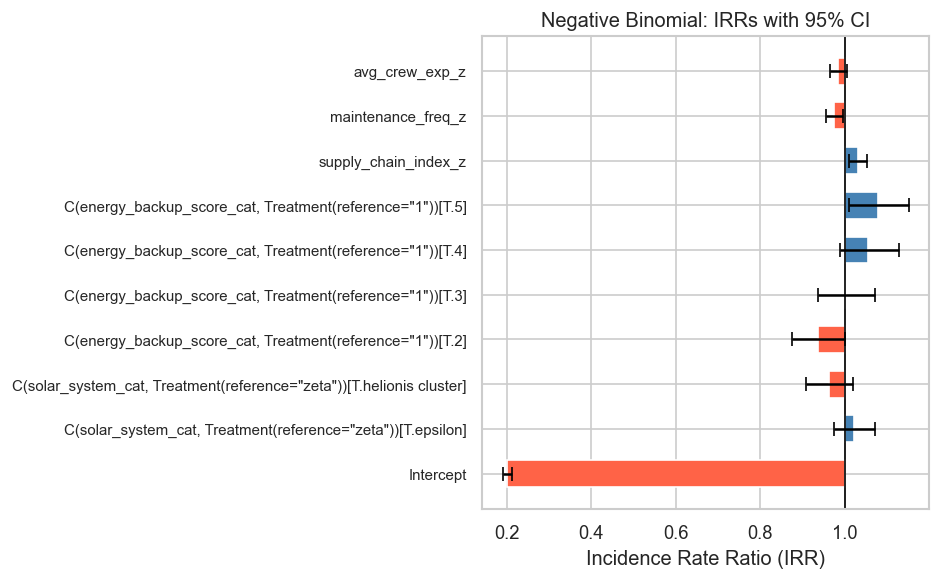

In [20]:
coef_df = pd.DataFrame({
    'coef':    freq_glm.params,
    'IRR':     np.exp(freq_glm.params),
    'IRR_lb':  np.exp(freq_glm.conf_int()[0]),
    'IRR_ub':  np.exp(freq_glm.conf_int()[1]),
    'p_value': freq_glm.pvalues
})
print('Incidence Rate Ratios (IRR = exp(coef)):')
print(coef_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(coef_df))
ax.barh(y_pos, coef_df['IRR']-1, left=1,
        color=['steelblue' if v>0 else 'tomato' for v in (coef_df['IRR']-1)],
        edgecolor='white', height=0.6)
ax.errorbar(coef_df['IRR'], y_pos,
            xerr=[coef_df['IRR']-coef_df['IRR_lb'], coef_df['IRR_ub']-coef_df['IRR']],
            fmt='none', color='black', capsize=4, lw=1.5)
ax.axvline(1, color='black', lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(coef_df.index, fontsize=9)
ax.set_xlabel('Incidence Rate Ratio (IRR)')
ax.set_title('Negative Binomial: IRRs with 95% CI')
plt.tight_layout(); plt.show()

In [21]:
# ========== Debug: Check categorical values ==========

print('Solar system values:')
print(freq_model_df['solar_system_cat'].unique())
print(f'\nValue counts:\n{freq_model_df["solar_system_cat"].value_counts()}')

print('\n\nEnergy backup score values:')
print(freq_model_df['energy_backup_score_cat'].unique())
print(f'\nValue counts:\n{freq_model_df["energy_backup_score_cat"].value_counts()}')

print('\n\nSafety compliance values:')
print(freq_model_df['safety_compliance_cat'].unique())
print(f'\nValue counts:\n{freq_model_df["safety_compliance_cat"].value_counts()}')


Solar system values:
['helionis cluster' 'epsilon' 'zeta']

Value counts:
solar_system_cat
zeta                38900
epsilon             38856
helionis cluster    19409
Name: count, dtype: int64


Energy backup score values:
['2', '4', '3', '1', '5', NaN]
Categories (5, object): ['1' < '2' < '3' < '4' < '5']

Value counts:
energy_backup_score_cat
2    19706
5    19501
4    19465
1    19324
3    19162
Name: count, dtype: int64


Safety compliance values:
['4', '5', '1', '2', '3', NaN]
Categories (5, object): ['1' < '2' < '3' < '4' < '5']

Value counts:
safety_compliance_cat
4    19573
2    19522
3    19455
1    19385
5    19226
Name: count, dtype: int64


---
## 4. Severity Model -- Gamma GLM

### 4.1 Model Overview

Unlike the frequency model (which predicts claim **counts**), the severity model predicts claim **amounts**—the size of individual claims that occur.

Since the business interruption dataset lacks an insured value variable (unlike cargo loss with severity ratios), we model **claim amount directly** using a **Gamma Generalized Linear Model (Gamma GLM)**.

#### Why Gamma Distribution for Claim Amount?

Insurance claim amounts exhibit characteristics well-suited to the Gamma distribution:

1. **Positive support**: Claims must be positive ($\text{claim\_amount} > 0$), which Gamma naturally enforces
2. **Right-skewed**: Most claims are moderate with occasional large claims—a characteristic Gamma shape
3. **Variance scaling with mean**: Gamma variance increases with the mean ($Var \propto E^2$), matching insurance data patterns

The Gamma distribution is parameterized as:

$$
\text{claim\_amount}_i \sim \text{Gamma}(\alpha_i, \beta)
$$

where:
- $\alpha_i = \mu_i / \beta$ (shape parameter, depends on predictors through $\mu_i$)
- $\beta$ (rate parameter, estimated from data)
- $E[\text{claim}_i] = \mu_i$, $Var[\text{claim}_i] = \mu_i^2 / \beta$

#### Model Specification

$$
\log(\mu_i) = \gamma_0 + \sum_{k=\text{alpha}}^{\text{zeta}}\gamma_{\text{sys},k}\,\mathbf{1}[\text{solar\_system}_i=k] + \gamma_{\text{prod}}\,z_{\text{prod},i} + \gamma_{\text{energy}}\,z_{\text{energy},i} + \gamma_{\text{safety}}\,z_{\text{safety},i}
$$

where $z_{\cdot,i}$ denotes z-score standardised predictors.

- **Response:** `claim_amount` (positive, continuous)  
- **Family:** Gamma with log link
- **`solar_system`** -- categorical, 6 levels (reference = zeta)  
- **Continuous predictors**: production_load, energy_backup_score, safety_compliance (z-score standardised)

In [22]:
sev_model_df = sev_clean.copy()

# Categorical predictor - nominal (solar_system)
sev_model_df['solar_system_cat'] = sev_model_df['solar_system'].str.strip().str.lower()

# Standardise continuous predictors
sev_std = {}
for col in ['production_load', 'energy_backup_score', 'safety_compliance']:
    mu = sev_model_df[col].mean()
    sd = sev_model_df[col].std()
    sev_std[col] = {'mean': mu, 'std': sd}
    sev_model_df[f'{col}_z'] = (sev_model_df[col] - mu) / sd
    print(f'{col}: mean={mu:.4f}, std={sd:.4f}')

# Drop rows missing any model variable
mvars_sev = ['claim_amount', 'production_load', 'energy_backup_score', 'safety_compliance', 'solar_system']
sev_model_df = sev_model_df.dropna(subset=mvars_sev)

print(f'\nSeverity model rows: {len(sev_model_df):,}')
print(f'claim_amount: min={sev_model_df["claim_amount"].min():,.2f}, '
      f'max={sev_model_df["claim_amount"].max():,.2f}, '
      f'mean={sev_model_df["claim_amount"].mean():,.2f}')

production_load: mean=0.4960, std=0.2866
energy_backup_score: mean=3.0526, std=1.4219
safety_compliance: mean=3.0041, std=1.4177

Severity model rows: 9,800
claim_amount: min=28,265.00, max=142,583,386.00, mean=4,361,180.60


In [23]:
# ========== Gamma GLM for Severity ==========

sev_formula = (
    'claim_amount ~ C(solar_system_cat, Treatment(reference="zeta"))'
    ' + energy_backup_score_z + safety_compliance_z'
)

sev_glm = smf.glm(
    formula=sev_formula,
    data=sev_model_df,
    family = sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(sev_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           claim_amount   No. Observations:                 9800
Model:                            GLM   Df Residuals:                     9795
Model Family:                   Gamma   Df Model:                            4
Link Function:                    Log   Scale:                          2.8264
Method:                          IRLS   Log-Likelihood:            -1.6142e+05
Date:                Thu, 26 Mar 2026   Deviance:                       13974.
Time:                        21:13:32   Pearson chi2:                 2.77e+04
No. Iterations:                    12   Pseudo R-squ. (CS):          0.0008961
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [24]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===== Extract GLM statistics =====
print("========== Severity Model Diagnostics ==========")

print("Log-Likelihood:", sev_glm.llf)
print("AIC:", sev_glm.aic)
print("Deviance:", sev_glm.deviance)
print("Pearson Chi-Square:", sev_glm.pearson_chi2)
print("Residual Degrees of Freedom:", sev_glm.df_resid)
print("Model Degrees of Freedom:", sev_glm.df_model)
print("Number of Observations:", sev_glm.nobs)

# ===== Predictions =====
y_true = sev_model_df['claim_amount']
y_pred = sev_glm.predict(sev_model_df)

# ===== Regression performance metrics =====
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n========== Predictive Performance ==========")
print("RMSE:", rmse)
print("MAE:", mae)
print("R-squared:", r2)

# ===== Normalised error metrics =====
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAPE (%):", mape)

========== Severity Model Diagnostics ==========
Log-Likelihood: -161416.10117126442
AIC: 322842.20234252885
Deviance: 13974.087853321347
Pearson Chi-Square: 27684.964663505583
Residual Degrees of Freedom: 9795
Model Degrees of Freedom: 4
Number of Observations: 9800

========== Predictive Performance ==========
RMSE: 7394511.030707778
MAE: 3921858.43278326
R-squared: 0.0008809013203939786
MAPE (%): 344.0657281271952


In [25]:
# ============================================
# Gamma Severity Parameter Extraction (Correct)
# ============================================

import numpy as np

# Predicted mean severities from GLM
mu_pred = sev_glm.predict(sev_model_df)

# Portfolio mean severity
mu_hat = np.mean(mu_pred)

# Dispersion parameter
phi_hat = sev_glm.scale

# Gamma parameters
shape_hat = 1 / phi_hat
scale_hat = phi_hat * mu_hat

print("Business Interruption")
print()
print("Severity Gamma")
print(f"Mean:       {mu_hat:.2f}")
print(f"Dispersion: {phi_hat:.6f}")
print(f"Shape:      {shape_hat:.4f}")
print(f"Scale:      {scale_hat:.2f}")
print()

print(f"Claim Severity ~ Gamma(shape={shape_hat:.4f}, scale={scale_hat:.2f})")

Business Interruption

Severity Gamma
Mean:       4361218.86
Dispersion: 2.826438
Shape:      0.3538
Scale:      12326716.69

Claim Severity ~ Gamma(shape=0.3538, scale=12326716.69)


### 4.2 Model Diagnostics

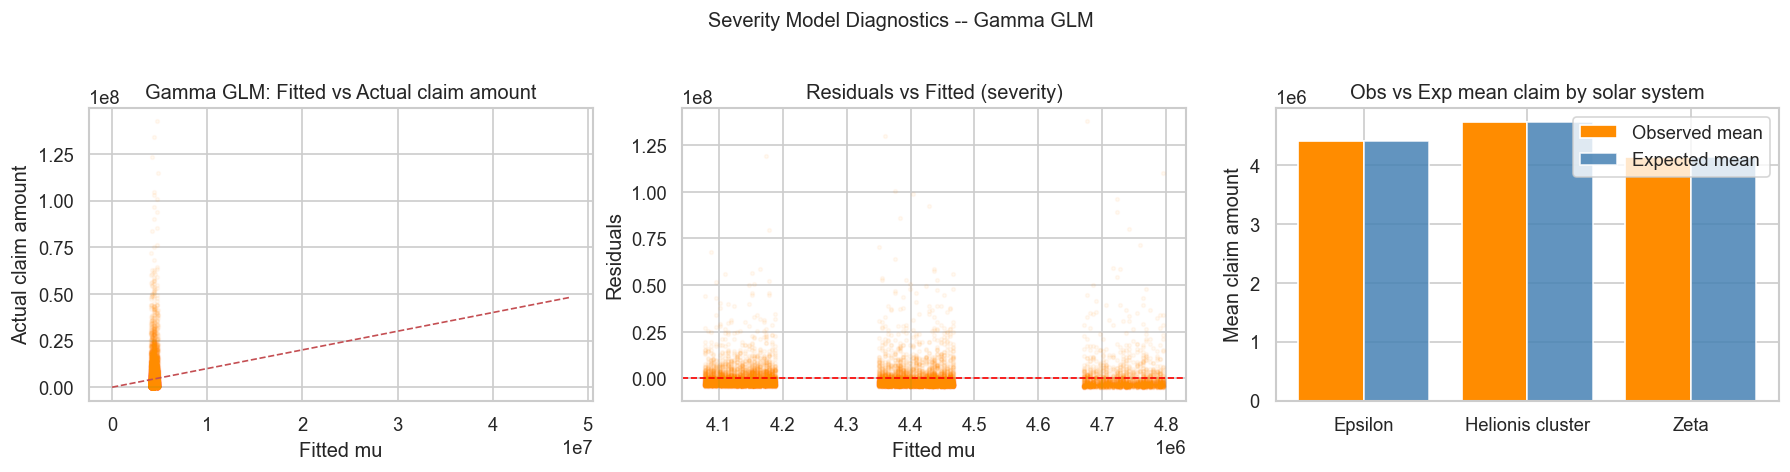

In [26]:
sev_model_df['fitted_mu_sev'] = sev_glm.fittedvalues
sev_model_df['resid_sev'] = sev_model_df['claim_amount'] - sev_model_df['fitted_mu_sev']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fitted vs Actual
lim_s = sev_model_df['claim_amount'].quantile(0.995)
axes[0].scatter(sev_model_df['fitted_mu_sev'], sev_model_df['claim_amount'],
                alpha=0.05, s=5, color='darkorange')
axes[0].plot([0, lim_s], [0, lim_s], 'r--', lw=1)
axes[0].set_title('Gamma GLM: Fitted vs Actual claim amount')
axes[0].set_xlabel('Fitted mu'); axes[0].set_ylabel('Actual claim amount')

# Residuals vs Fitted
axes[1].scatter(sev_model_df['fitted_mu_sev'], sev_model_df['resid_sev'],
                alpha=0.05, s=5, color='darkorange')
axes[1].axhline(0, color='red', lw=1, ls='--')
axes[1].set_title('Residuals vs Fitted (severity)')
axes[1].set_xlabel('Fitted mu'); axes[1].set_ylabel('Residuals')

# Obs vs Exp by solar system
grp_s = sev_model_df.groupby('solar_system').agg(
    obs=('claim_amount', 'mean'), exp=('fitted_mu_sev', 'mean')
).reset_index()
x = np.arange(len(grp_s))
axes[2].bar(x-0.2, grp_s['obs'], 0.4, label='Observed mean', color='darkorange')
axes[2].bar(x+0.2, grp_s['exp'], 0.4, label='Expected mean', color='steelblue', alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(grp_s['solar_system'].str.capitalize())
axes[2].set_title('Obs vs Exp mean claim by solar system')
axes[2].set_ylabel('Mean claim amount')
axes[2].legend()

plt.suptitle('Severity Model Diagnostics -- Gamma GLM', fontsize=12)
plt.tight_layout(); plt.show()

Severity model -- coefficients (log scale) and exponentiated parameters:
                                                                         coef      exp_coef   exp_coef_lb   exp_coef_ub  p_value
Intercept                                                             15.2348  4.134281e+06  3.922726e+06  4.357244e+06   0.0000
C(solar_system_cat, Treatment(reference="zeta"))[T.epsilon]            0.0645  1.066600e+00  9.905000e-01  1.148600e+00   0.0877
C(solar_system_cat, Treatment(reference="zeta"))[T.helionis cluster]   0.1353  1.144900e+00  1.043800e+00  1.255800e+00   0.0041
energy_backup_score_z                                                  0.0078  1.007900e+00  9.749000e-01  1.042000e+00   0.6444
safety_compliance_z                                                    0.0015  1.001500e+00  9.687000e-01  1.035400e+00   0.9316


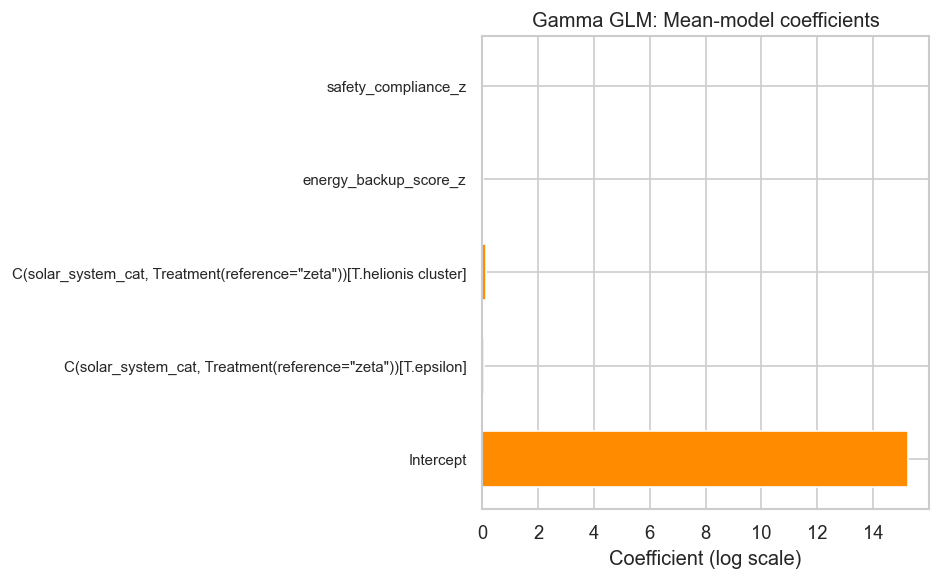

In [27]:
coef_sev_df = pd.DataFrame({
    'coef':    sev_glm.params,
    'exp_coef': np.exp(sev_glm.params),
    'exp_coef_lb': np.exp(sev_glm.conf_int()[0]),
    'exp_coef_ub': np.exp(sev_glm.conf_int()[1]),
    'p_value': sev_glm.pvalues
})

print('Severity model -- coefficients (log scale) and exponentiated parameters:')
print(coef_sev_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(coef_sev_df))
ax.barh(y_pos, coef_sev_df['coef'],
        color=['darkorange' if v>0 else 'steelblue' for v in coef_sev_df['coef']],
        edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(coef_sev_df.index, fontsize=9)
ax.set_xlabel('Coefficient (log scale)')
ax.set_title('Gamma GLM: Mean-model coefficients')
plt.tight_layout(); plt.show()

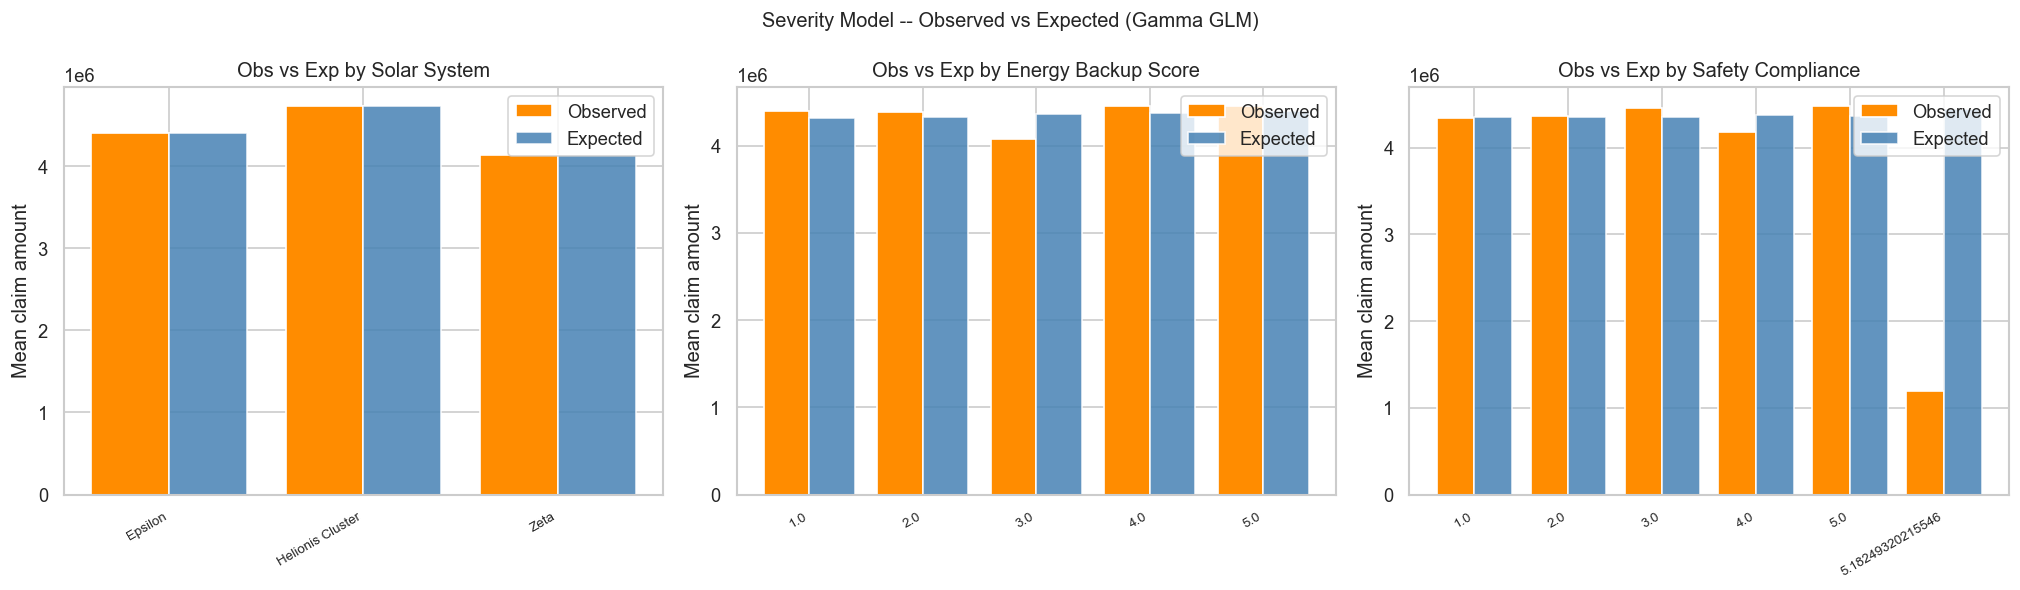

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, title in zip(axes,
        ['solar_system', 'energy_backup_score', 'safety_compliance'],
        ['Solar System', 'Energy Backup Score', 'Safety Compliance']):
    grp = sev_model_df.groupby(col).agg(
        obs=('claim_amount', 'mean'), exp=('fitted_mu_sev', 'mean')
    ).reset_index()
    x = np.arange(len(grp))
    ax.bar(x - 0.2, grp['obs'], 0.4, label='Observed', color='darkorange')
    ax.bar(x + 0.2, grp['exp'], 0.4, label='Expected', color='steelblue', alpha=0.85)
    ax.set_xticks(x)
    labels = grp[col].astype(str)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'Obs vs Exp by {title}')
    ax.set_ylabel('Mean claim amount')
    ax.legend()

plt.suptitle('Severity Model -- Observed vs Expected (Gamma GLM)', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
# -----------------------------
# Pricing (adapted from Equipment Failure)
# -----------------------------
pricing_df = freq_model_df.copy()

# Predicted claims from frequency model (uses exposure offset)
pricing_df['pred_claims'] = freq_glm.predict(pricing_df)

# Convert to claim rate per exposure unit
pricing_df['freq_rate'] = pricing_df['pred_claims'] / pricing_df['exposure']

# Ensure severity z-columns exist (sev_glm used z-scored predictors)
for col in ['production_load', 'energy_backup_score', 'safety_compliance']:
    zcol = f'{col}_z'
    if zcol not in pricing_df.columns:
        if col in sev_std:
            mu = sev_std[col]['mean']
            sd = sev_std[col]['std']
            pricing_df[zcol] = (pricing_df[col] - mu) / sd
        else:
            mu = freq_std.get(col, {}).get('mean', pricing_df[col].mean())
            sd = freq_std.get(col, {}).get('std', pricing_df[col].std())
            pricing_df[zcol] = (pricing_df[col] - mu) / sd

# Ensure solar_system_cat exists for prediction
if 'solar_system_cat' not in pricing_df.columns:
    pricing_df['solar_system_cat'] = pricing_df['solar_system'].str.strip().str.lower()

# Predicted severity (mean claim amount) from severity model
pricing_df['pred_severity'] = sev_glm.predict(pricing_df)

# Pure premium = expected claim rate × expected severity
pricing_df['pure_premium'] = pricing_df['pred_claims'] * pricing_df['pred_severity']

# Loadings (match Equipment Failure)
expense_loading = 0.15
profit_loading = 0.10

pricing_df['technical_premium'] = pricing_df['pure_premium'] * (1 + expense_loading + profit_loading)

# Summarise pricing by solar system and station
pricing_summary = pricing_df.groupby(['solar_system_cat','station_id']).agg(
    pure_premium=('pure_premium','mean'),
    technical_premium=('technical_premium','mean')
).reset_index()

print(pricing_summary)


    solar_system_cat  station_id   pure_premium  technical_premium
0            epsilon          A1  921742.084882       1.152178e+06
1            epsilon  A1_???2026  907127.196906       1.133909e+06
2            epsilon  A1_???5071  894789.020696       1.118486e+06
3            epsilon          A2  920144.284511       1.150180e+06
4            epsilon  A2_???3795  942063.189030       1.177579e+06
..               ...         ...            ...                ...
241             zeta          G9  845794.150039       1.057243e+06
242             zeta  G9_???2114  813548.130201       1.016935e+06
243             zeta  G9_???2751  794029.157624       9.925364e+05
244             zeta  G9_???2814  907464.090222       1.134330e+06
245             zeta  G9_???7369  814425.280208       1.018032e+06

[246 rows x 4 columns]


In [30]:
import numpy as np
import pandas as pd

# -----------------------------
# Helper: rebuild columns needed for prediction
# -----------------------------
def prepare_prediction_df(df, freq_std, sev_std):
    df = df.copy()

    # solar system category used by both models
    if 'solar_system_cat' not in df.columns:
        df['solar_system_cat'] = df['solar_system'].astype(str).str.strip().str.lower()

    # Create z-scored columns if missing
    for col in ['production_load', 'energy_backup_score', 'safety_compliance',
                'maintenance_freq', 'supply_chain_index']:
        zcol = f'{col}_z'
        if zcol not in df.columns and col in df.columns:
            if col in sev_std:
                mu = sev_std[col]['mean']
                sd = sev_std[col]['std']
            elif col in freq_std:
                mu = freq_std[col]['mean']
                sd = freq_std[col]['std']
            else:
                mu = df[col].mean()
                sd = df[col].std()

            if sd == 0:
                df[zcol] = 0.0
            else:
                df[zcol] = (df[col] - mu) / sd

    return df


# -----------------------------
# Helper: simulate aggregate annual loss
# -----------------------------
def simulate_aggregate_losses(
    df,
    freq_glm,
    sev_glm,
    freq_std,
    sev_std,
    n_sims=20000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    df = prepare_prediction_df(df, freq_std, sev_std)

    # -------- Frequency prediction --------
    mu_N = freq_glm.predict(df, offset=np.log(df['exposure']))

    # Clean predictions
    mu_N = np.clip(mu_N, 1e-8, None)   # avoid negative or zero
    mu_N = np.nan_to_num(mu_N, nan=1e-8)

    # Get NB dispersion parameter
    alpha = getattr(freq_glm.family, 'alpha', None)

    if alpha is None or alpha <= 0:
        alpha = 1.0  # fallback if model doesn't store alpha

    # numpy parameterisation
    n_param = 1.0 / alpha
    p_param = 1.0 / (1.0 + alpha * mu_N)

    # Ensure valid probability range
    p_param = np.clip(p_param, 1e-6, 1 - 1e-6)

    counts = rng.negative_binomial(
        n=n_param,
        p=p_param,
        size=(n_sims, len(df))
    )

    # -------- Severity prediction --------
    mu_X = sev_glm.predict(df)

    # Clean predictions
    mu_X = np.clip(mu_X, 1e-6, None)
    mu_X = np.nan_to_num(mu_X, nan=1e-6)

    phi = sev_glm.scale
    phi = max(phi, 1e-8)

    k = 1.0 / phi
    theta = phi * mu_X

    # Aggregate severity by row:
    # Sum of n iid Gamma(k, theta) = Gamma(n*k, theta)
    shape_matrix = counts * k

    losses = np.where(
        counts > 0,
        rng.gamma(shape=shape_matrix, scale=theta, size=shape_matrix.shape),
        0.0
    )

    # Portfolio annual loss = sum across all insured rows/stations
    aggregate_losses = losses.sum(axis=1)

    return aggregate_losses


# -----------------------------
# Helper: summarise aggregate loss distribution
# -----------------------------
def summarise_loss_distribution(losses):
    losses = np.asarray(losses)

    var95 = np.quantile(losses, 0.95)
    var99 = np.quantile(losses, 0.99)

    summary = {
        'Expected Annual Loss': losses.mean(),
        'Variance': losses.var(ddof=1),
        'Standard Deviation': losses.std(ddof=1),
        '95% VaR': var95,
        '99% VaR': var99,
        '95% TVaR': losses[losses >= var95].mean(),
        '99% TVaR': losses[losses >= var99].mean(),
        'Min': losses.min(),
        'Median': np.median(losses),
        'Max': losses.max()
    }

    return pd.Series(summary)


# -----------------------------
# Run baseline aggregate model
# -----------------------------
baseline_losses = simulate_aggregate_losses(
    df=pricing_df,
    freq_glm=freq_glm,
    sev_glm=sev_glm,
    freq_std=freq_std,
    sev_std=sev_std,
    n_sims=20000,
    random_state=42
)

baseline_metrics = summarise_loss_distribution(baseline_losses)
print(baseline_metrics)

Expected Annual Loss    4.324958e+10
Variance                7.438394e+17
Standard Deviation      8.624612e+08
95% VaR                 4.468373e+10
99% VaR                 4.528282e+10
95% TVaR                4.504238e+10
99% TVaR                4.554297e+10
Min                     4.011519e+10
Median                  4.324095e+10
Max                     4.631972e+10
dtype: float64


In [31]:
def simulate_aggregate_losses(
    df,
    freq_glm,
    sev_glm,
    freq_std,
    sev_std,
    n_sims=20000,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    df = prepare_prediction_df(df, freq_std, sev_std)

    # ---------- Frequency ----------
    mu_N = freq_glm.predict(df, offset=np.log(df['exposure']))
    mu_N = np.clip(mu_N, 1e-8, None)   # avoid negatives / zero
    mu_N = np.nan_to_num(mu_N, nan=1e-8)

    # Simulate counts using Poisson
    counts = rng.poisson(
        lam=mu_N,
        size=(n_sims, len(df))
    )

    # ---------- Severity ----------
    mu_X = sev_glm.predict(df)
    mu_X = np.clip(mu_X, 1e-6, None)
    mu_X = np.nan_to_num(mu_X, nan=1e-6)

    phi = sev_glm.scale
    phi = max(phi, 1e-8)

    k = 1.0 / phi
    theta = phi * mu_X

    shape_matrix = counts * k

    losses = np.where(
        counts > 0,
        rng.gamma(shape=shape_matrix, scale=theta, size=shape_matrix.shape),
        0.0
    )

    aggregate_losses = losses.sum(axis=1)

    return aggregate_losses

In [32]:
def backup_tier(x):
    if x <= 2:
        return "Weak"
    elif x == 3:
        return "Moderate"
    else:
        return "Strong"

freq_clean['backup_tier'] = freq_clean['energy_backup_score'].apply(backup_tier)
sev_clean['backup_tier'] = sev_clean['energy_backup_score'].apply(backup_tier)

In [33]:
freq_clean['product_class'] = (
    freq_clean['solar_system'] + "_" + freq_clean['backup_tier']
)

sev_clean['product_class'] = (
    sev_clean['solar_system'] + "_" + sev_clean['backup_tier']
)

In [34]:
freq_summary = (
    freq_clean
    .groupby('product_class')
    .agg(
        exposure=('exposure','sum'),
        claims=('claim_count','sum')
    )
)

freq_summary['freq'] = freq_summary['claims'] / freq_summary['exposure']

freq_summary

,exposure,claims,freq
product_class,,,
Epsilon_Moderate,3741.269000,729,0.194854
Epsilon_Strong,7767.186000,1668,0.214750
Epsilon_Weak,7849.906287,1580,0.201276
Helionis Cluster_Moderate,1944.172000,404,0.207801
Helionis Cluster_Strong,3908.122378,769,0.196770
Helionis Cluster_Weak,3850.323000,704,0.182842
Zeta_Moderate,3849.235000,765,0.198741
Zeta_Strong,7791.293000,1681,0.215754
Zeta_Weak,7829.868993,1473,0.188126


In [35]:
sev_summary = (
    sev_clean
    .groupby('product_class')
    .agg(
        avg_severity=('claim_amount','mean'),
        median_severity=('claim_amount','median'),
        claims=('claim_amount','count')
    )
)

sev_summary

,avg_severity,median_severity,claims
product_class,,,
Epsilon_Moderate,4.003731e+06,1826287.0,735
Epsilon_Strong,4.440526e+06,2083884.0,1666
Epsilon_Weak,4.563151e+06,2247673.0,1587
Helionis Cluster_Moderate,5.200253e+06,2219092.0,399
Helionis Cluster_Strong,4.556111e+06,2134671.0,770
Helionis Cluster_Weak,4.659942e+06,2195298.0,707
Zeta_Moderate,3.577193e+06,2008363.0,764
Zeta_Strong,4.424077e+06,2273545.0,1693
Zeta_Weak,4.095042e+06,2194708.0,1479


In [36]:
premium_table = freq_summary.merge(
    sev_summary,
    left_index=True,
    right_index=True,
    how='left'
)

premium_table['pure_premium'] = (
    premium_table['freq'] * premium_table['avg_severity']
)

premium_table

,exposure,claims_x,freq,avg_severity,median_severity,claims_y,pure_premium
product_class,,,,,,,
Epsilon_Moderate,3741.269000,729,0.194854,4.003731e+06,1826287.0,735,7.801417e+05
Epsilon_Strong,7767.186000,1668,0.214750,4.440526e+06,2083884.0,1666,9.536011e+05
Epsilon_Weak,7849.906287,1580,0.201276,4.563151e+06,2247673.0,1587,9.184540e+05
Helionis Cluster_Moderate,1944.172000,404,0.207801,5.200253e+06,2219092.0,399,1.080615e+06
Helionis Cluster_Strong,3908.122378,769,0.196770,4.556111e+06,2134671.0,770,8.965045e+05
Helionis Cluster_Weak,3850.323000,704,0.182842,4.659942e+06,2195298.0,707,8.520322e+05
Zeta_Moderate,3849.235000,765,0.198741,3.577193e+06,2008363.0,764,7.109341e+05
Zeta_Strong,7791.293000,1681,0.215754,4.424077e+06,2273545.0,1693,9.545109e+05
Zeta_Weak,7829.868993,1473,0.188126,4.095042e+06,2194708.0,1479,7.703829e+05


In [37]:
expense_loading = 0.20
profit_loading = 0.10

premium_table['technical_premium'] = (
    premium_table['pure_premium']
    * (1 + expense_loading + profit_loading)
)

premium_table

,exposure,claims_x,freq,avg_severity,median_severity,claims_y,pure_premium,technical_premium
product_class,,,,,,,,
Epsilon_Moderate,3741.269000,729,0.194854,4.003731e+06,1826287.0,735,7.801417e+05,1.014184e+06
Epsilon_Strong,7767.186000,1668,0.214750,4.440526e+06,2083884.0,1666,9.536011e+05,1.239681e+06
Epsilon_Weak,7849.906287,1580,0.201276,4.563151e+06,2247673.0,1587,9.184540e+05,1.193990e+06
Helionis Cluster_Moderate,1944.172000,404,0.207801,5.200253e+06,2219092.0,399,1.080615e+06,1.404800e+06
Helionis Cluster_Strong,3908.122378,769,0.196770,4.556111e+06,2134671.0,770,8.965045e+05,1.165456e+06
Helionis Cluster_Weak,3850.323000,704,0.182842,4.659942e+06,2195298.0,707,8.520322e+05,1.107642e+06
Zeta_Moderate,3849.235000,765,0.198741,3.577193e+06,2008363.0,764,7.109341e+05,9.242143e+05
Zeta_Strong,7791.293000,1681,0.215754,4.424077e+06,2273545.0,1693,9.545109e+05,1.240864e+06
Zeta_Weak,7829.868993,1473,0.188126,4.095042e+06,2194708.0,1479,7.703829e+05,1.001498e+06
